# Notebook 04b - Comparative TSTR Experiments, underperformance task (target_low_perf)

**Authors:** Ivo Rambaldi & Tommaso Petrelli  
**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

---

## Overview

Auto-generated mirror of `G4_TSTR_Experiments_No_Enforcing.ipynb`, re-targeted at the symmetric lower-tail ("underperformance", score <= 25th percentile) detection task instead of excellence detection, following Marrero et al. (ECAI 2024). All logic is identical; only `dataset.target_column` and the output paths differ (config cell below).

This notebook implements **Goal 4** of the project: we evaluate how replacing real training data with synthetically generated data affects two dimensions that matter for responsible machine learning:

- **Utility**: how accurately can the model predict high academic performance?
- **Fairness**: how equitably are predictions distributed across groups defined by circumstances (socioeconomic status, gender, parental education, etc.) that are beyond a student's control?

The evaluation protocol is **Train on Synthetic, Test on Real (TSTR)**: each classifier is trained on one of the synthetic datasets (or the real training set, as a baseline) and evaluated on the *same* real held-out test set. This setup isolates the causal effect of the training data on downstream behaviour; any change in utility or fairness can be attributed directly to the synthetic generation process, not to the test conditions.

### Experiment grid

| Dimension | Values |
|-----------|--------|
| **Training data** | Real (baseline), Copula, CTGAN, SMOTE, TVAE |
| **Classifiers** | Logistic Regression, XGBoost, MLP |
| **Utility metrics** | Balanced Accuracy, F1-macro, ROC-AUC, Brier Score, MMD |
| **Fairness metrics** | DPD, EOD, DI (per protected attribute and averaged) |

Hyperparameters are fixed across all experiments (see `config/config.yaml`) so that results differences are attributable solely to training data, not to tuning differences.

All outputs (metrics CSVs, figures) are written to `results/experiments/` and `results/figures/experiments/`. The final analysis and interpretation of these results is left to **Notebook 5**.

## 1. Environment Setup

### 1.1 Path and import setup

In [20]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd

# Suppress warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Ensure the project root is on sys.path so 'src' imports resolve correctly
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.logging import get_logger


logger = get_logger('notebook_04')

logger.info(f"Environment ready. Project root: {PROJECT_ROOT}")

2026-07-10 09:32:27 | INFO     | notebook_04 | Environment ready. Project root: D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526


### 1.2 Load configuration

In [21]:
from src.utils.config import load_config
from src.data.persistence import ensure_dir


# Load config.yaml
cfg = load_config(PROJECT_ROOT / 'config' / 'config.yaml')

# Goal 4b: re-target at the underperformance task and route outputs to a
# dedicated sub-directory so this run never overwrites Goal 4's target_high_perf
# results.
cfg['dataset']['target_column'] = cfg['target']['low_column_name']
cfg['paths']['experiments_dir'] = cfg['paths']['experiments_dir'] / 'low_perf'
cfg['paths']['figures_dir']     = cfg['paths']['figures_dir'] / 'low_perf'

# Resolve output directories and create them if necessary.
EXPERIMENTS_DIR = Path(cfg["paths"]["experiments_dir"])
FIGURES_DIR     = Path(cfg["paths"]["figures_dir"])
ensure_dir(EXPERIMENTS_DIR)
ensure_dir(FIGURES_DIR)

# Print key config values for reproducibility
methods     = cfg["generation"]["methods"]
classifiers = [k for k, v in cfg["experiments"]["classifiers"].items() if v.get("enabled", True)]
protected   = cfg["dataset"]["protected_attributes"]

print('=== Configuration summary ===')
print(f"Seed                : {cfg['seed']}")
print(f"Generation methods  : {methods}")
print(f"Classifiers         : {classifiers}")
print(f"Protected attributes: {len(protected)}")
print(f"Total experiments   : {(len(methods) + 1) * len(classifiers)}")

=== Configuration summary ===
Seed                : 42
Generation methods  : {'ctgan': {'epochs': 300, 'batch_size': 500}, 'tvae': {'epochs': 300, 'batch_size': 500}, 'gaussian_copula': {'none': 0}, 'smote': {'k_neighbors': 5}}
Classifiers         : ['logistic_regression', 'xgboost', 'mlp']
Protected attributes: 12
Total experiments   : 15


## 2. Data Loading

We load:
1. The **real train / test splits** produced by Notebook 1 (Goal 1). These are the reference datasets.
2. One **synthetic training dataset per generation method** produced by Notebook 2 (Goal 2).

The real test set is never used for training or generation; it serves exclusively as the evaluation target throughout all experiments.

In [22]:
from src.data.loader import load_real_data, load_synthetic_dataset


# Load real data (baseline)
real_train_df, real_test_df = load_real_data(cfg)

logger.info(f"Real train: {real_train_df.shape}")
logger.info(f"Real test : {real_test_df.shape}")

# Load synthetic datasets. Low-perf variant swaps SMOTE for its low-perf-balanced
# counterpart ("smote_low_perf", produced by G2 5.4b); the other three methods are
# shared with G4_TSTR_Experiments_No_Enforcing.ipynb since they never condition on
# the target column (see G2 5.4b markdown for rationale).
METHODS = ["ctgan", "tvae", "gaussian_copula", "smote_low_perf"]
synthetic_datasets = {m: load_synthetic_dataset(cfg, m) for m in METHODS}

for method, df in synthetic_datasets.items():
    logger.info(f"Synthetic [{method}]: {df.shape}")

2026-07-10 09:32:27 | INFO     | src.data.loader | Loading real train data from D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\Data\train.csv
2026-07-10 09:32:27 | INFO     | src.data.loader | Loading real test data  from D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\Data\test.csv
2026-07-10 09:32:28 | INFO     | notebook_04 | Real train: (58128, 42)
2026-07-10 09:32:28 | INFO     | notebook_04 | Real test : (14533, 42)
2026-07-10 09:32:28 | INFO     | src.data.loader | Loading synthetic data [ctgan] from D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\synthetic\ctgan\synthetic_ctgan.csv
2026-07-10 09:32:28 | INFO     | src.data.loader | Loading synthetic data [tvae] from D:\Users\Utente\OneD

### 2.1 Target distribution check

Before running experiments, we verify the class distribution in the real test set and across all training datasets. Substantial imbalance in the training sets could confound comparisons between methods unless handled consistently. All classifiers are configured with a `class_weight` or `scale_pos_weight` argument to address this.

In [23]:
rows = []
for label, df in {
    "real_train": real_train_df,
    "real_test":  real_test_df,
    **synthetic_datasets,
}.items():
    counts = df[cfg['dataset']['target_column']].value_counts(normalize=True)
    rows.append({
        "dataset":       label,
        "n_samples":     len(df),
        "positive_rate": round(counts.get(1, 0.0), 4),
        "negative_rate": round(counts.get(0, 0.0), 4),
    })

dist_df = pd.DataFrame(rows)
display(dist_df)

,dataset,n_samples,positive_rate,negative_rate
0,real_train,58128,0.2500,0.7500
1,real_test,14533,0.2510,0.7490
2,ctgan,58128,0.3807,0.6193
3,tvae,58128,0.0927,0.9073
4,gaussian_copula,58128,0.2503,0.7497
5,smote_low_perf,87192,0.5000,0.5000


## 3. Full TSTR Experiment Matrix

We now run every combination of (training dataset, classifier) via a shared
`Evaluator` (`src/evaluation/evaluator.py`), the same class Notebook 03 uses for
its baseline validation. It:

1. Trains the classifier on the given training data (encoded with the same
   OrdinalEncoder + StandardScaler fit on the real training set, so
   LogisticRegression/MLP receive fully numerical input).
2. Evaluates predictions on the real test set.
3. Computes utility metrics, per-attribute and mean fairness metrics, MMD, and
   correlation deltas.

`Evaluator.baseline()` anchors the real-data reference for a given classifier;
`Evaluator.evaluate()` scores a synthetic training set against that same
classifier/reference (TSTR).

In [24]:
from src.data.preprocessing import get_feature_columns
from src.data.preprocessor import DataSplit, fit_feature_encoders, apply_feature_encoders
from src.evaluation.evaluator import Evaluator
from src.models.classifiers import CLASSIFIER_DISPLAY_NAMES

target_col      = cfg["dataset"]["target_column"]
protected_attrs = cfg["dataset"]["protected_attributes"]

# Pre-compute feature columns from the real training set so all
# experiments use exactly the same feature set.
feature_columns = get_feature_columns(real_train_df, cfg)
logger.info(
    f"Feature set: {len(feature_columns)} columns derived from real training data."
)

# Fit feature encoders once on the real training set; reuse for the real
# test set and every synthetic training set (LogisticRegression/MLP need
# fully numerical input).
enc, scaler, cat_cols, num_cols = fit_feature_encoders(real_train_df[feature_columns])

X_train_real = apply_feature_encoders(real_train_df[feature_columns], enc, scaler, cat_cols, num_cols)
X_test_real  = apply_feature_encoders(real_test_df[feature_columns],  enc, scaler, cat_cols, num_cols)

present_protected = [a for a in protected_attrs if a in real_train_df.columns]
missing_protected = [a for a in protected_attrs if a not in real_train_df.columns]
if missing_protected:
    logger.warning(
        f"{len(missing_protected)} configured protected attributes not present "
        f"in the data — skipping: {missing_protected}"
    )

split = DataSplit(
    X_train         = X_train_real,
    X_test          = X_test_real,
    y_train         = real_train_df[target_col].astype(int),
    y_test          = real_test_df[target_col].astype(int),
    protected_train = real_train_df[present_protected].copy(),
    protected_test  = real_test_df[present_protected].copy(),
    feature_names   = feature_columns,
    target_name     = target_col,
    protected_attrs = present_protected,
    encoders        = {"ordinal": enc},
    scaler          = scaler,
)

evaluator = Evaluator(split, cfg)
print(f"DataSplit ready. X_train={split.X_train.shape}  X_test={split.X_test.shape}  "
      f"protected={len(present_protected)}")

2026-07-10 09:32:29 | INFO     | notebook_04 | Feature set: 40 columns derived from real training data.


2026-07-10 09:32:30 | WARNING  | notebook_04 | 4 configured protected attributes not present in the data — skipping: ['s_birth_country', 'p_public_or_private', 'p_island', 'p_percentage_of_teachers_changed_school_last_year']
DataSplit ready. X_train=(58128, 40)  X_test=(14533, 40)  protected=8


In [25]:
classifiers    = list(cfg["experiments"]["classifiers"].keys())
baseline_label = cfg["experiments"]["baseline_label"]

rows = []
per_attr_fairness = {baseline_label: {}, **{m: {} for m in synthetic_datasets}}

# Loop classifier-outer / method-inner so Evaluator.baseline() correctly
# anchors the real-data reference before each classifier's synthetic runs.
for clf_name in classifiers:
    logger.info(f"==> [{baseline_label} | {CLASSIFIER_DISPLAY_NAMES[clf_name]}]")
    result = evaluator.baseline(clf_name)
    result = {**result, "mmd": 0.0}  # MMD(real, real) = 0 by definition
    per_attr_fairness[baseline_label][clf_name] = evaluator.last_fairness_detail
    rows.append({"method": baseline_label, "classifier": clf_name, **result})

    for method, syn_df in synthetic_datasets.items():
        logger.info(f"==> [{method} | {CLASSIFIER_DISPLAY_NAMES[clf_name]}]")

        missing = [c for c in feature_columns if c not in syn_df.columns]
        if missing:
            logger.warning(f"  [{method}] {len(missing)} feature cols absent — filled with 0.")
        X_synth_raw = pd.DataFrame(
            {c: syn_df[c] if c in syn_df.columns else 0.0 for c in feature_columns},
            index=syn_df.index,
        )
        X_synth = apply_feature_encoders(X_synth_raw, enc, scaler, cat_cols, num_cols)
        y_synth = syn_df[target_col].astype(int)

        result = evaluator.evaluate(
            X_synth         = X_synth,
            y_synth         = y_synth,
            classifier_name = clf_name,
            generator_name  = method,
            X_real_for_mmd  = split.X_train,
        )
        per_attr_fairness[method][clf_name] = evaluator.last_fairness_detail
        rows.append({"method": result.pop("generator"), "classifier": result.pop("classifier"), **result})

metrics_df = pd.DataFrame(rows)

# Reorder columns for readability.
id_cols    = ["method", "classifier"]
util_cols  = [
    c for c in ["balanced_accuracy", "f1_macro", "roc_auc", "brier_score", "mmd"]
    if c in metrics_df.columns
]
fair_cols  = [c for c in metrics_df.columns if c.startswith("mean_")]
extra_cols = [c for c in metrics_df.columns if c not in id_cols + util_cols + fair_cols]
metrics_df = metrics_df[id_cols + util_cols + fair_cols + extra_cols]

logger.info(f"Experiment matrix complete. Shape: {metrics_df.shape}")
display(metrics_df)

2026-07-10 09:32:30 | INFO     | notebook_04 | ==> [real | Logistic Regression]
2026-07-10 09:32:30 | INFO     | src.evaluation.evaluator | Computing real-data baseline for [logistic_regression] …
2026-07-10 09:32:30 | INFO     | src.evaluation.evaluator |   [real] AUC=0.6913 | BA=0.6384
2026-07-10 09:32:30 | INFO     | notebook_04 | ==> [ctgan | Logistic Regression]
2026-07-10 09:32:31 | INFO     | src.evaluation.evaluator | Evaluating [ctgan | logistic_regression | rep=0] …
2026-07-10 09:32:31 | INFO     | src.evaluation.evaluator |   [synthetic] AUC=0.6740 | BA=0.6241
2026-07-10 09:32:35 | INFO     | notebook_04 | ==> [tvae | Logistic Regression]
2026-07-10 09:32:35 | INFO     | src.evaluation.evaluator | Evaluating [tvae | logistic_regression | rep=0] …
2026-07-10 09:32:36 | INFO     | src.evaluation.evaluator |   [synthetic] AUC=0.6626 | BA=0.5944
2026-07-10 09:32:40 | INFO     | notebook_04 | ==> [gaussian_copula | Logistic Regression]
2026-07-10 09:32:40 | INFO     | src.evaluat

,method,classifier,balanced_accuracy,f1_macro,roc_auc,brier_score,mmd,mean_dpd,mean_eod,mean_di,...,f_ESCS_dpd,f_ESCS_eod,f_ESCS_di,f_ESCS_odds_ratio,repetition,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,corr_mean_abs_delta,corr_max_abs_delta
0,real,logistic_regression,0.638365,0.582701,0.691270,0.224220,0.000000,0.393563,0.396165,0.343056,...,0.523497,0.509991,0.223352,2.716554,NaN,NaN,NaN,NaN,NaN,NaN
1,ctgan,logistic_regression,0.624147,0.586180,0.673957,0.221937,0.005153,0.398342,0.427147,0.273951,...,0.566446,0.604286,0.108344,5.067878,0.0,0.014218,-0.003479,0.017313,0.041030,0.332857
2,tvae,logistic_regression,0.594381,0.599462,0.662565,0.226548,0.012141,0.202297,0.268689,0.226121,...,0.282029,0.364503,0.076951,6.804010,0.0,0.043984,-0.016761,0.028705,NaN,NaN
3,gaussian_copula,logistic_regression,0.609015,0.556255,0.647357,0.233395,0.005352,0.433215,0.447119,0.304935,...,0.665076,0.690287,0.094953,6.603504,0.0,0.029351,0.026446,0.043913,0.071240,0.719367
4,smote_low_perf,logistic_regression,0.626473,0.600107,0.682773,0.209159,0.009508,0.361038,0.408985,0.254372,...,0.479534,0.541798,0.136857,4.560385,0.0,0.011893,-0.017407,0.008497,0.018886,0.669709
5,real,xgboost,0.649124,0.597257,0.706989,0.218237,0.000000,0.392613,0.417101,0.326789,...,0.558083,0.588185,0.163192,3.523404,NaN,NaN,NaN,NaN,NaN,NaN
6,ctgan,xgboost,0.621577,0.583314,0.673840,0.222353,0.005153,0.382752,0.405788,0.301733,...,0.541302,0.552873,0.139290,3.953411,0.0,0.027546,0.013943,0.033149,0.041030,0.332857
7,tvae,xgboost,0.532326,0.516063,0.640981,0.205033,0.012141,0.071652,0.091099,0.253411,...,0.106172,0.140472,0.061982,10.692553,0.0,0.116798,0.081194,0.066009,NaN,NaN
8,gaussian_copula,xgboost,0.600521,0.551105,0.641070,0.235576,0.005352,0.412356,0.419557,0.322768,...,0.582278,0.584932,0.166851,4.144957,0.0,0.048602,0.046152,0.065919,0.071240,0.719367
9,smote_low_perf,xgboost,0.578908,0.552698,0.627441,0.325290,0.009508,0.381506,0.405390,0.265506,...,0.508906,0.529016,0.144680,5.424500,0.0,0.070216,0.044559,0.079549,0.018886,0.669709


### 3.1 Save the raw results matrix

The full metrics matrix is persisted as a CSV for downstream use in Notebook 5 (analysis and interpretation) and for reproducibility.

In [26]:
from src.data.persistence import save_csv


metrics_path = EXPERIMENTS_DIR / "metrics_matrix.csv"
save_csv(metrics_df, metrics_path)
logger.info(f"Metrics matrix saved to: {metrics_path}")

2026-07-10 09:36:51 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\metrics_matrix.csv
2026-07-10 09:36:51 | INFO     | notebook_04 | Metrics matrix saved to: D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\metrics_matrix.csv


## 4. Delta Analysis

Raw metric values already tell us something, but the key quantity of interest is the **delta**: how much does each metric change when we switch from real to synthetic training data? We define:

$$\Delta m_{\text{method, clf}} = m_{\text{method, clf}} - m_{\text{real, clf}}$$

A negative delta on a metric where higher is better (balanced accuracy, F1, AUC, DI) indicates degradation. A positive delta on a metric where lower is better (Brier Score, DPD, EOD) indicates degradation.

This formulation keeps the baseline classifier-specific: we compare CTGAN-XGBoost against Real-XGBoost, not against Real-LogReg, so that classifier effects do not confound the comparison.

In [27]:
from src.evaluation.delta import (
    compute_delta_matrix,
    get_utility_delta_columns,
    get_fairness_delta_columns
)


delta_df = compute_delta_matrix(metrics_df, cfg)

# Select only the synthetic rows (exclude the baseline)
baseline_label = cfg["experiments"]["baseline_label"]
delta_syn = delta_df[delta_df["method"] != baseline_label].copy()

util_delta_cols  = get_utility_delta_columns(delta_df)
fair_delta_cols  = get_fairness_delta_columns(delta_df)

logger.info(f"Utility delta columns: {util_delta_cols}")
logger.info(f"Fairness delta columns: {fair_delta_cols}")
display(delta_syn[["method", "classifier"] + util_delta_cols + fair_delta_cols])

2026-07-10 09:36:52 | INFO     | notebook_04 | Utility delta columns: ['delta_balanced_accuracy', 'delta_f1_macro', 'delta_roc_auc', 'delta_brier_score', 'delta_mmd']
2026-07-10 09:36:52 | INFO     | notebook_04 | Fairness delta columns: ['delta_mean_dpd', 'delta_mean_eod', 'delta_mean_di', 'delta_mean_odds_ratio']


,method,classifier,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,delta_brier_score,delta_mmd,delta_mean_dpd,delta_mean_eod,delta_mean_di,delta_mean_odds_ratio
1,ctgan,logistic_regression,-0.014218,0.003479,-0.017313,-0.002283,0.005153,0.004779,0.030981,-0.069105,1.254629
2,tvae,logistic_regression,-0.043984,0.016761,-0.028705,0.002329,0.012141,-0.191266,-0.127477,-0.116935,2.795309
3,gaussian_copula,logistic_regression,-0.029351,-0.026446,-0.043913,0.009175,0.005352,0.039653,0.050954,-0.038121,0.948418
4,smote_low_perf,logistic_regression,-0.011893,0.017407,-0.008497,-0.015061,0.009508,-0.032525,0.012819,-0.088684,1.251698
6,ctgan,xgboost,-0.027546,-0.013943,-0.033149,0.004116,0.005153,-0.009860,-0.011313,-0.025055,0.590871
7,tvae,xgboost,-0.116798,-0.081194,-0.066009,-0.013205,0.012141,-0.320961,-0.326002,-0.073378,2.867975
8,gaussian_copula,xgboost,-0.048602,-0.046152,-0.065919,0.017339,0.005352,0.019743,0.002456,-0.004021,0.238897
9,smote_low_perf,xgboost,-0.070216,-0.044559,-0.079549,0.107053,0.009508,-0.011107,-0.011711,-0.061283,1.579205
11,ctgan,mlp,0.061071,0.079949,-0.023247,0.023518,0.005153,0.215207,0.239297,0.021205,-1.741283
12,tvae,mlp,0.013003,0.029823,-0.033408,0.050751,0.012141,0.046861,0.058812,-0.000320,0.326893


### 4.1 Save the delta matrix

In [28]:
delta_path = EXPERIMENTS_DIR / "delta_matrix.csv"
save_csv(delta_df, delta_path)
logger.info(f"Delta matrix saved to: {delta_path}")

2026-07-10 09:36:52 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\delta_matrix.csv
2026-07-10 09:36:52 | INFO     | notebook_04 | Delta matrix saved to: D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\delta_matrix.csv


### 4.2 Save per-attribute fairness breakdowns

In addition to the aggregated fairness summary, we save one CSV file per (method, classifier) pair containing the per-protected-attribute fairness breakdown. This granular data is essential for the analysis in Notebook 5, where we investigate which circumstances are most affected by synthetic data generation.

In [29]:
per_attr_dir = EXPERIMENTS_DIR / "per_attribute_fairness"
ensure_dir(per_attr_dir)

for method, clf_dict in per_attr_fairness.items():
    for clf_name, fair_df in clf_dict.items():
        filename = f"fairness_{method}_{clf_name}.csv"
        save_csv(fair_df, per_attr_dir / filename)

logger.info(f"Per-attribute fairness CSVs saved to: {per_attr_dir}")

2026-07-10 09:36:52 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\per_attribute_fairness\fairness_real_logistic_regression.csv
2026-07-10 09:36:52 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\per_attribute_fairness\fairness_real_xgboost.csv
2026-07-10 09:36:52 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\per_attribute_fairness\fairness_real_mlp.csv
2026-07-10 09:36:52 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Un

2026-07-10 09:36:52 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\per_attribute_fairness\fairness_tvae_xgboost.csv
2026-07-10 09:36:52 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\per_attribute_fairness\fairness_tvae_mlp.csv
2026-07-10 09:36:52 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\per_attribute_fairness\fairness_gaussian_copula_logistic_regression.csv
2026-07-10 09:36:52 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater S

## 5. Visualisations

Each figure addresses a specific analytical question:

| Figure | Question |
|--------|----------|
| 5.1 MMD | How faithfully does each method reproduce the real training distribution? |
| 5.2 Utility metrics | What is the absolute utility of each (method, classifier) combination? |
| 5.3 Fairness metrics | What is the absolute fairness of each configuration? |
| 5.4 Delta heat maps | Where are the biggest losses relative to the real baseline? |
| 5.5 Utility vs. fairness scatter | Are utility loss and fairness degradation correlated? |
| 5.6 Per-attribute breakdown | Which protected attributes are most affected by synthetic generation? |

### 5.1 Maximum Mean Discrepancy

MMD measures the distance between the distribution of synthetic training features and the real training features using an RBF kernel (bandwidth set via the median heuristic). A lower MMD indicates that the synthetic data more faithfully reproduces the real data's statistical structure.

MMD is independent of the downstream classifier — `Evaluator.evaluate()` recomputes it per (method, classifier) call for simplicity, but the value is identical across classifiers for a given method since it only depends on the training features.

2026-07-10 09:36:53 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\mmd_comparison.png


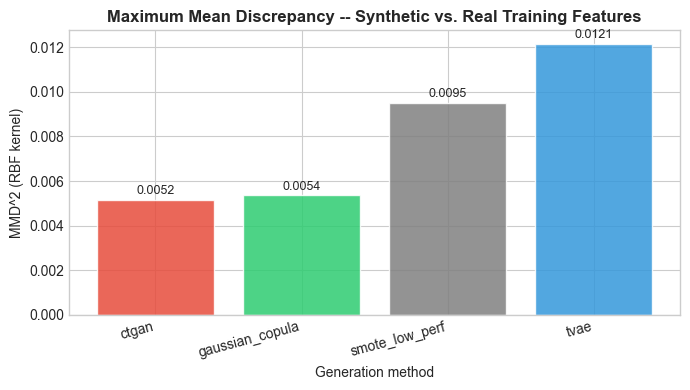

In [30]:
from src.utils.plotting import plot_mmd_bar


fig_mmd = plot_mmd_bar(metrics_df, cfg, save=True)
plt.show(); plt.close()

### 5.2 Utility metrics

We plot absolute utility metrics grouped by classifier, with one bar per generation method. The real baseline is always shown first for reference. Balanced accuracy is the primary metric given the class imbalance in the dataset; the remaining metrics (F1-macro, ROC-AUC, Brier Score) provide complementary perspectives on prediction quality.

2026-07-10 09:36:54 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\utility_balanced_accuracy.png


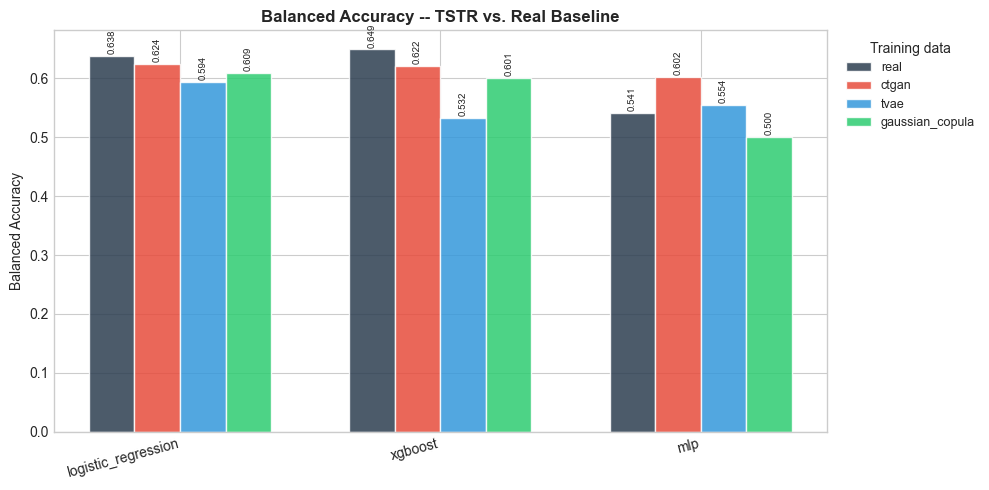

2026-07-10 09:36:55 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\utility_f1_macro.png


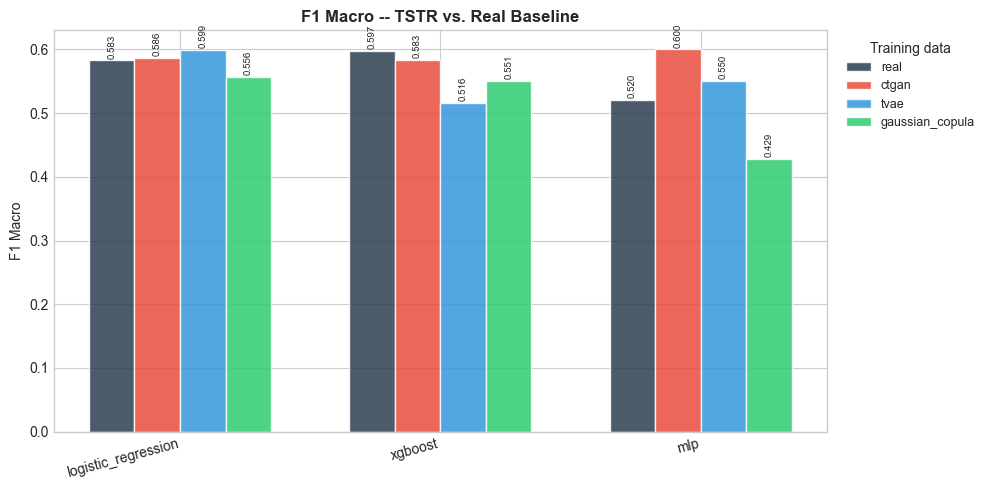

2026-07-10 09:36:56 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\utility_roc_auc.png


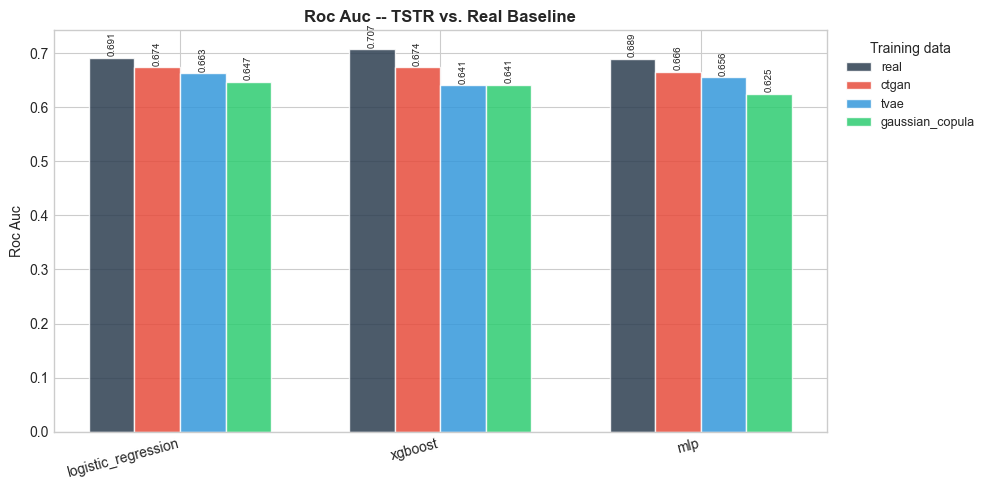

In [31]:
from src.utils.plotting import plot_utility_bar


utility_metric_cols = [
    m for m in cfg["experiments"]["utility_metrics"] if m != "mmd" and m in metrics_df.columns
]

for metric in utility_metric_cols:
    fig = plot_utility_bar(metrics_df, metric=metric, cfg=cfg, save=True)
    plt.show(); plt.close()

### 5.3 Fairness metrics

We plot the mean fairness metrics (averaged across all 12 protected attributes) per (method, classifier) combination. Recall the interpretation:

- **DPD** (Demographic Parity Difference): lower is fairer; 0 = perfect parity.
- **EOD** (Equalized Odds Difference): lower is fairer; 0 = equal TPR and FPR across groups.
- **DI** (Disparate Impact ratio): higher is fairer; DI < 0.8 triggers the legal four-fifths rule.

2026-07-10 09:36:57 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_dpd.png


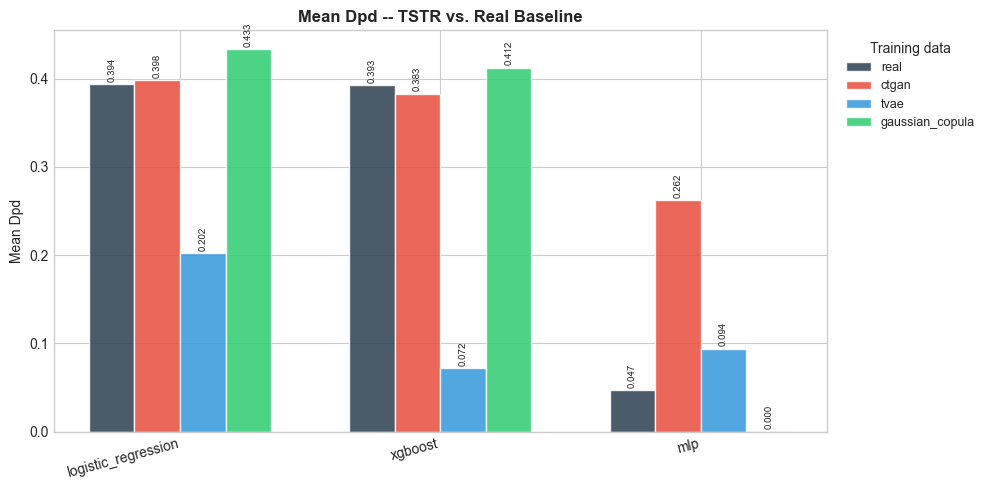

2026-07-10 09:36:58 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_eod.png


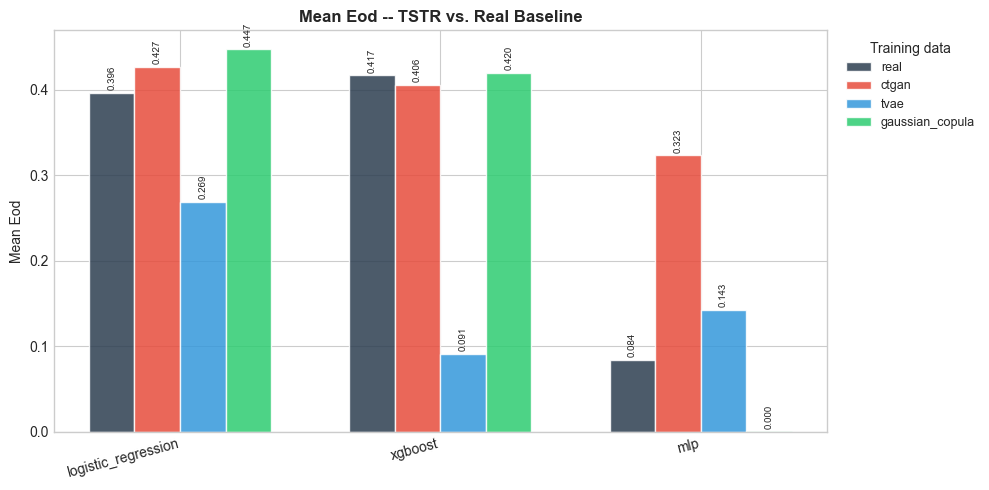

2026-07-10 09:37:01 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_di.png


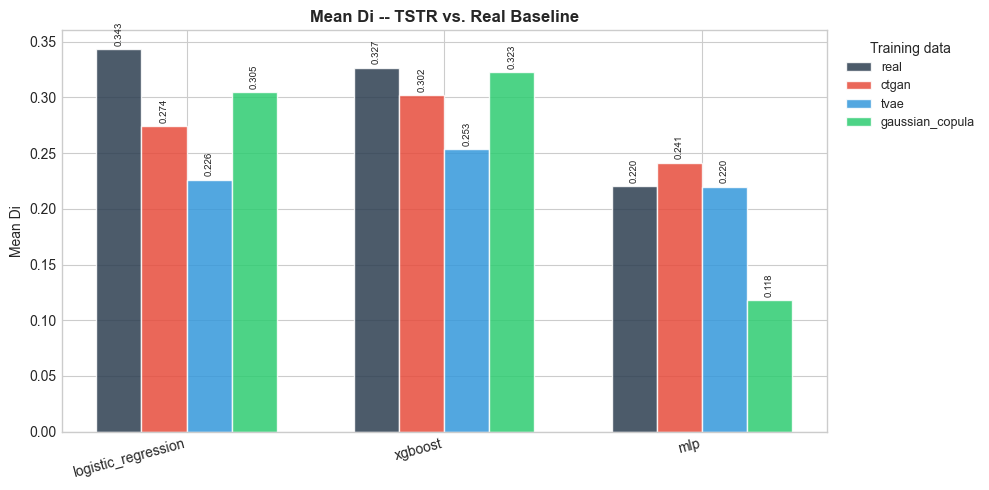

2026-07-10 09:37:02 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_odds_ratio.png


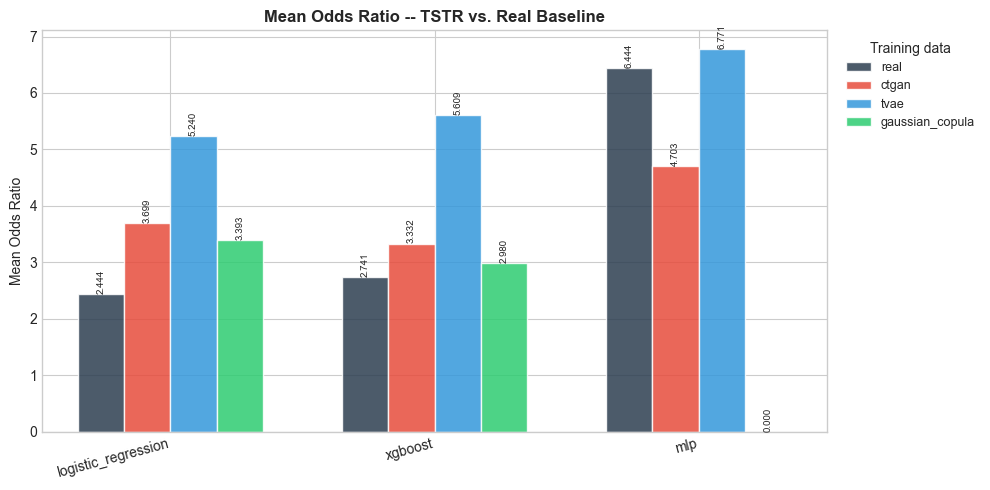

In [32]:
from src.utils.plotting import plot_fairness_bar


fairness_summary_cols = [c for c in metrics_df.columns if c.startswith("mean_")]

for metric in fairness_summary_cols:
    fig = plot_fairness_bar(metrics_df, metric=metric, cfg=cfg, save=True)
    plt.show(); plt.close()

### 5.4 Delta heatmaps

The heatmaps show the change in each metric relative to the real-data baseline for the same classifier. Red cells indicate degradation; blue cells indicate improvement. By convention, a cell is red when the synthetic model is worse than the real baseline for that metric.

2026-07-10 09:37:04 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\delta_heatmap_utility.png


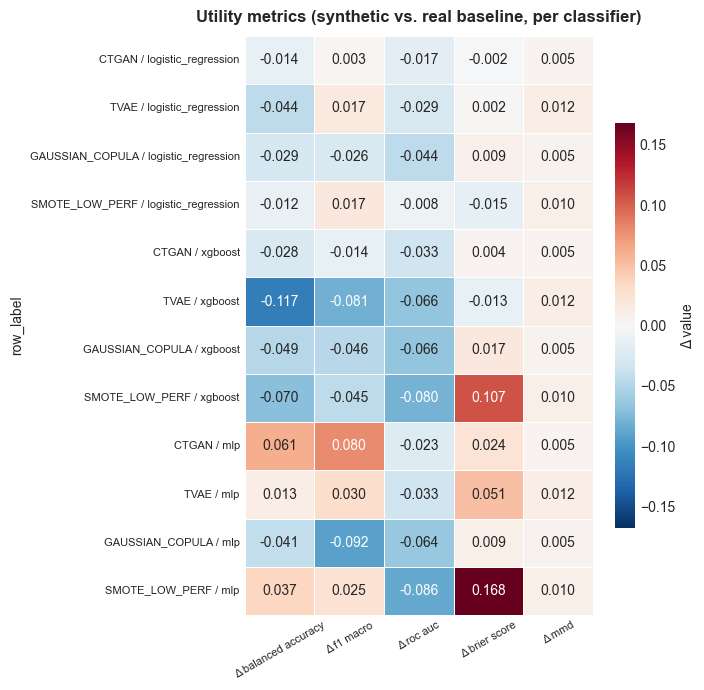

2026-07-10 09:37:05 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\delta_heatmap_fairness.png


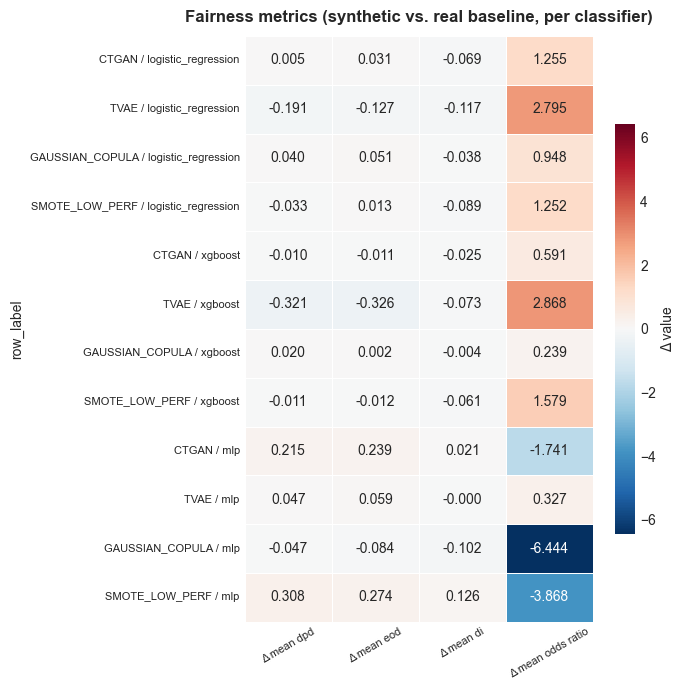

In [33]:
from src.utils.plotting import plot_delta_heatmap


# Utility delta heatmap
if util_delta_cols:
    fig = plot_delta_heatmap(
        delta_df,
        delta_columns=util_delta_cols,
        filename_suffix="utility",
        cfg=cfg,
        title="Utility metrics (synthetic vs. real baseline, per classifier)",
        save=True
    )
    plt.show(); plt.close()

# Fairness delta heatmap
if fair_delta_cols:
    fig = plot_delta_heatmap(
        delta_df,
        delta_columns=fair_delta_cols,
        filename_suffix="fairness",
        cfg=cfg,
        title="Fairness metrics (synthetic vs. real baseline, per classifier)",
        save=True
    )
    plt.show(); plt.close()

### 5.5 Utility loss vs. Fairness degradation

A central question of this project is whether utility loss and fairness degradation are correlated, i.e. whether the generation methods that lose the most accuracy also lose the most fairness, or whether these dimensions are largely independent. This scatter plot maps each (method, classifier) pair onto the utility–fairness delta plane.

The axes are oriented so that points further up and further left represent *jointly worse* outcomes on both dimensions. Points near the origin are close to the real baseline.

2026-07-10 09:37:07 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\scatter_utility_vs_fairness.png


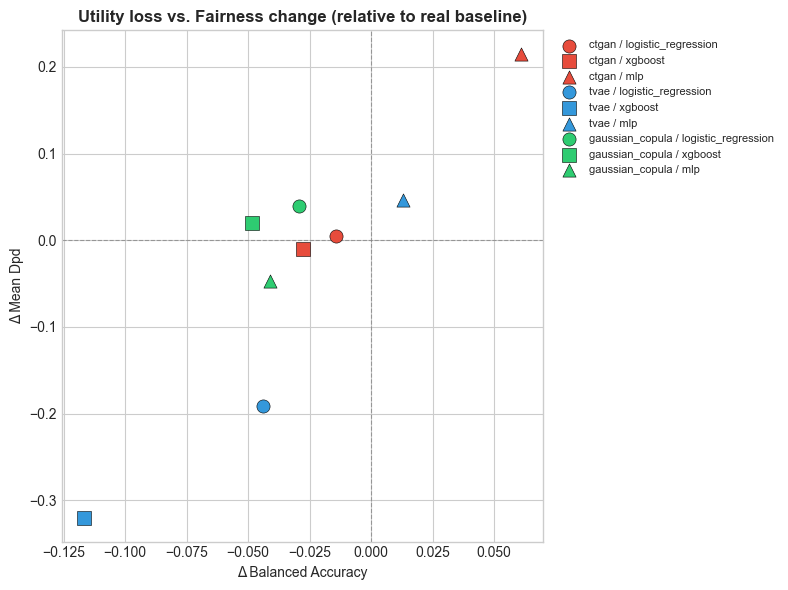

In [34]:
from src.utils.plotting import plot_utility_fairness_scatter


# Use balanced accuracy (primary utility metric) and mean DPD (primary fairness metric).
util_scatter_col = "delta_balanced_accuracy"
fair_scatter_col = "delta_mean_dpd"

if util_scatter_col in delta_df.columns and fair_scatter_col in delta_df.columns:
    fig = plot_utility_fairness_scatter(
        delta_df,
        utility_col=util_scatter_col,
        fairness_col=fair_scatter_col,
        cfg=cfg,
        save=True
    )
    plt.show(); plt.close()
else:
    logger.warning(
        f"Scatter requires '{util_scatter_col}' and '{fair_scatter_col}'. "
        "Check that balanced_accuracy and mean_dpd are in the metrics config."
    )

### 5.6 Per-attribute fairness breakdown

The aggregated fairness metrics in 5.3 summarise across all 12 protected attributes. Here we drill down to the per-attribute level for a selected (method, classifier) configuration. This is the most policy-relevant view: it identifies *which* groups (e.g., students with low parental education, immigrant students) are most harshly affected when a particular synthetic generation method is used.

We produce one breakdown plot per generation method using the classifier that showed the largest mean fairness degradation.

2026-07-10 09:37:08 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_rate_priv_ctgan_logistic_regression.png


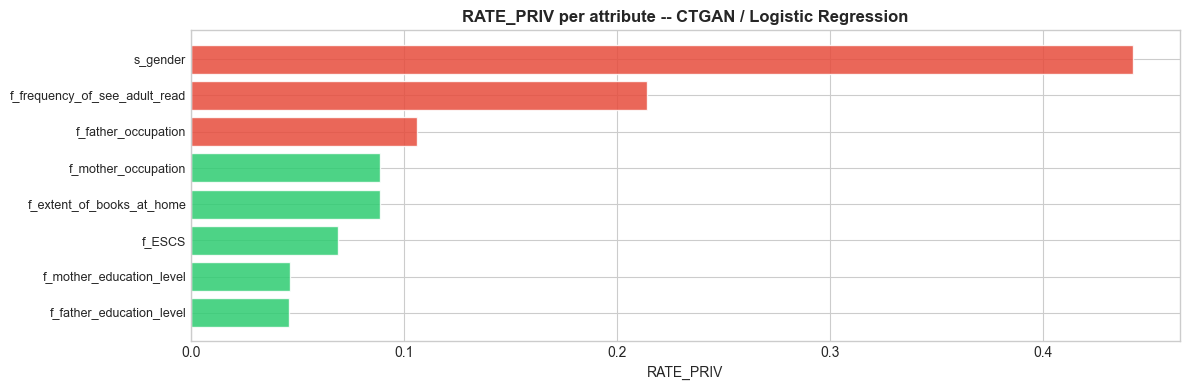

2026-07-10 09:37:08 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_rate_unpriv_ctgan_logistic_regression.png


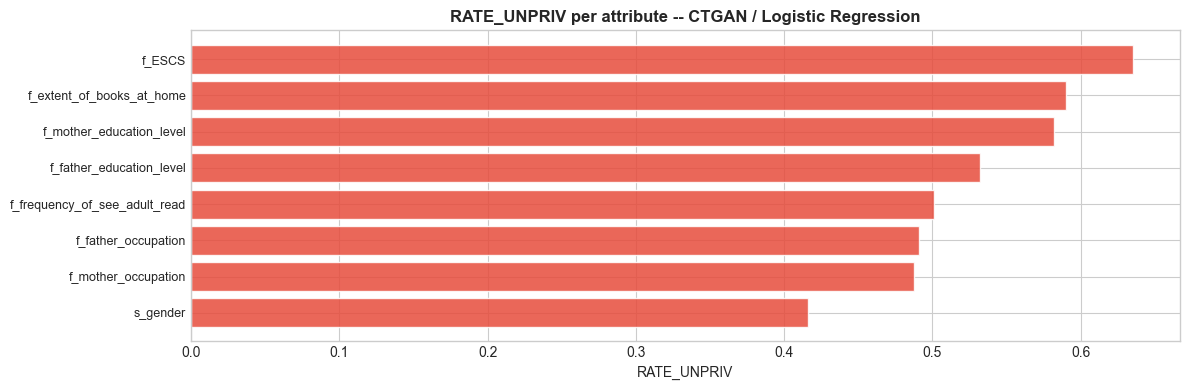

2026-07-10 09:37:09 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_tpr_priv_ctgan_logistic_regression.png


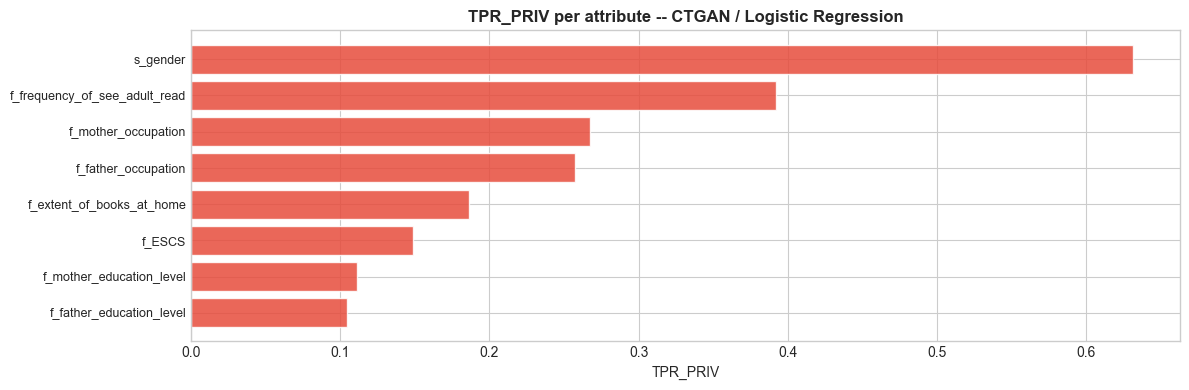

2026-07-10 09:37:10 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_tpr_unpriv_ctgan_logistic_regression.png


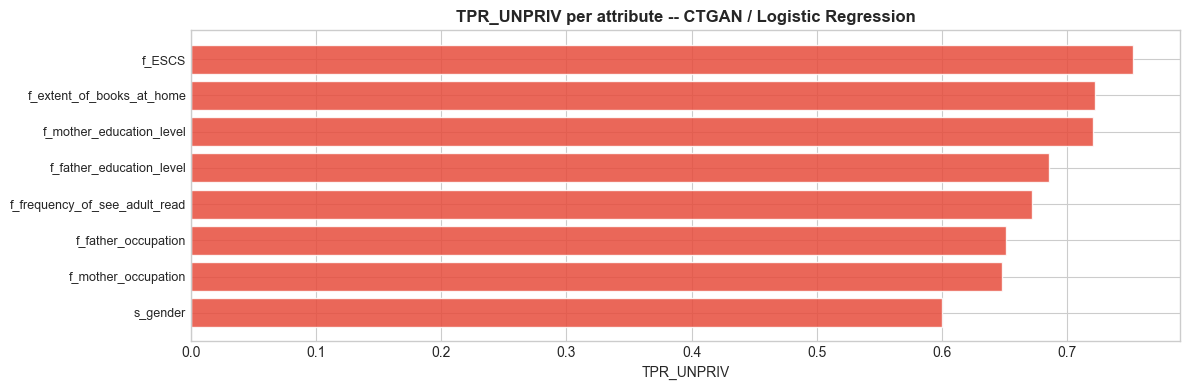

2026-07-10 09:37:10 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_fpr_priv_ctgan_logistic_regression.png


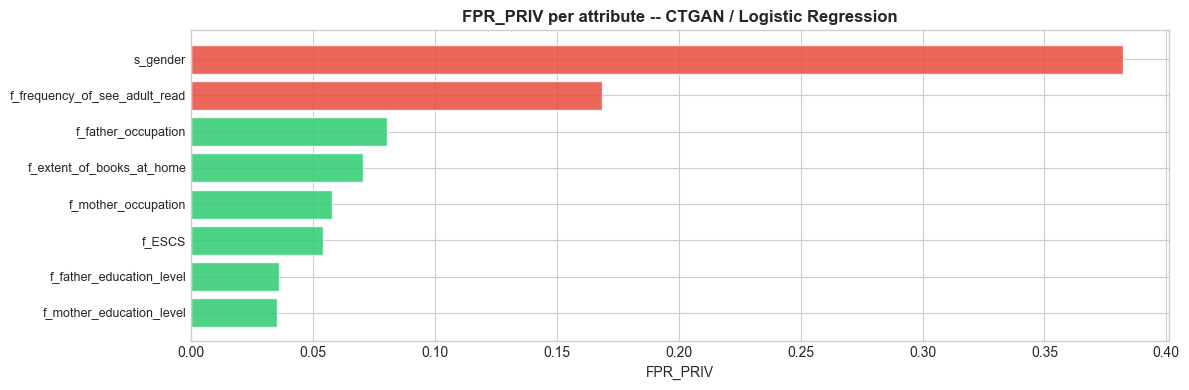

2026-07-10 09:37:11 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_fpr_unpriv_ctgan_logistic_regression.png


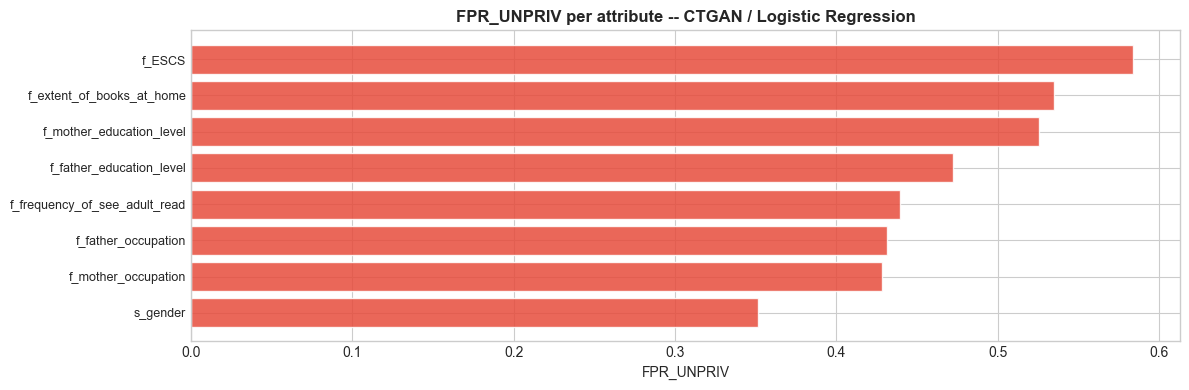

2026-07-10 09:37:12 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_ctgan_logistic_regression.png


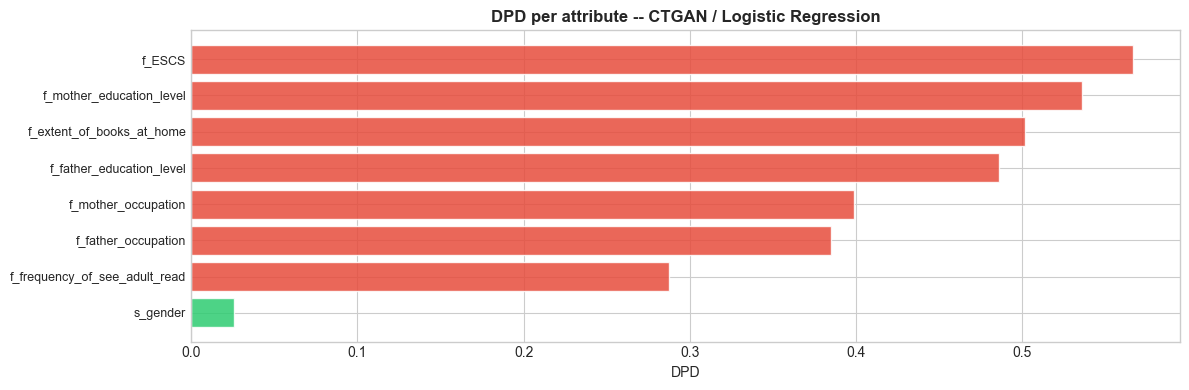

2026-07-10 09:37:12 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_delta_tpr_ctgan_logistic_regression.png


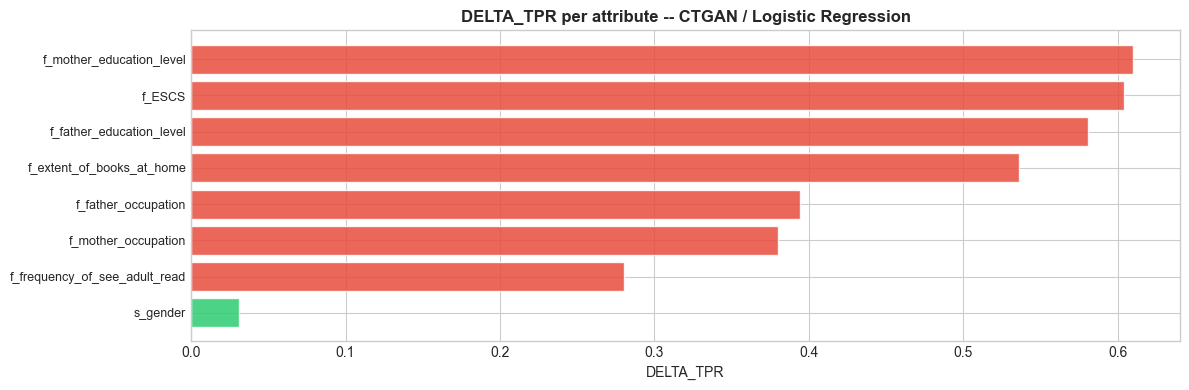

2026-07-10 09:37:13 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_delta_fpr_ctgan_logistic_regression.png


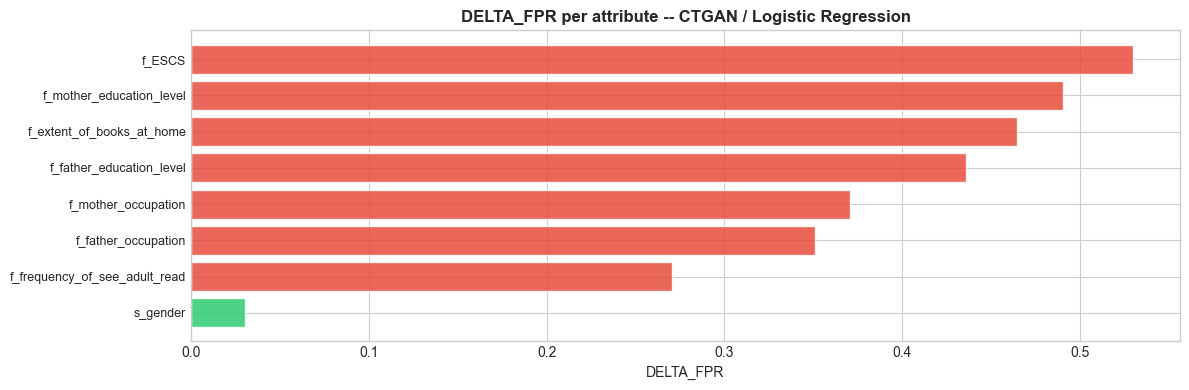

2026-07-10 09:37:14 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_ctgan_logistic_regression.png


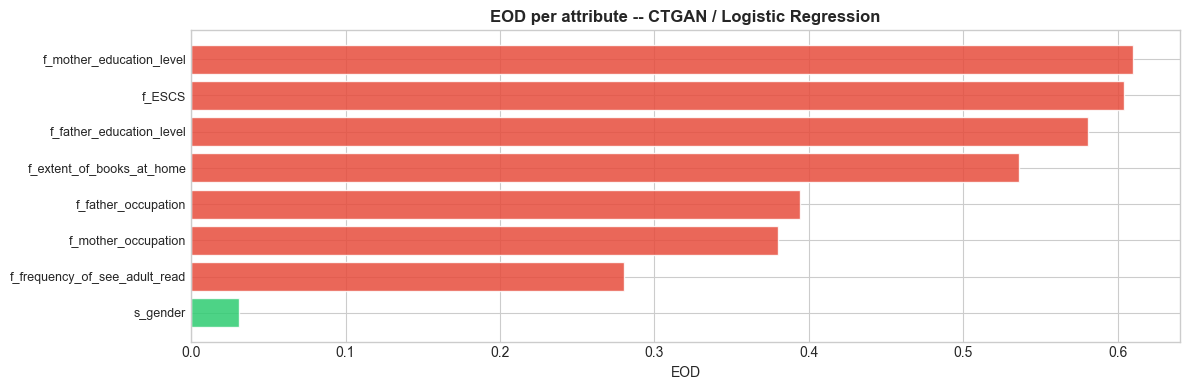

2026-07-10 09:37:14 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_ctgan_logistic_regression.png


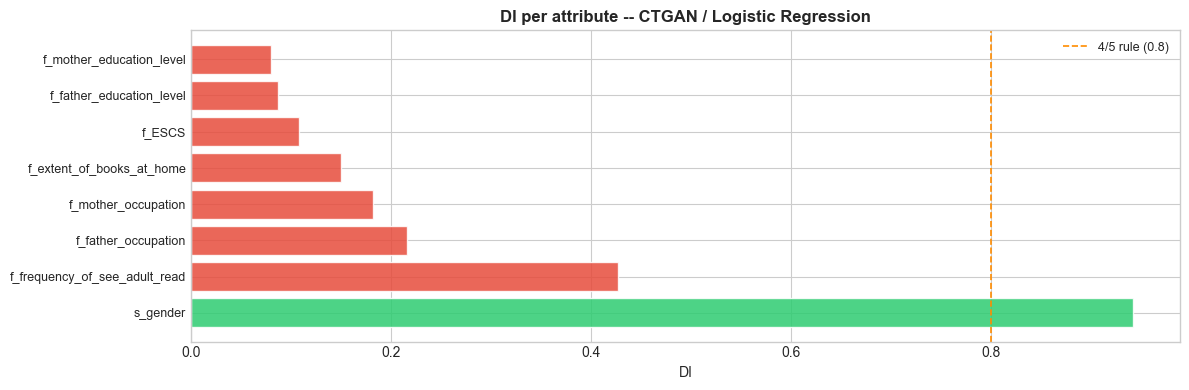

2026-07-10 09:37:15 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_odds_ratio_ctgan_logistic_regression.png


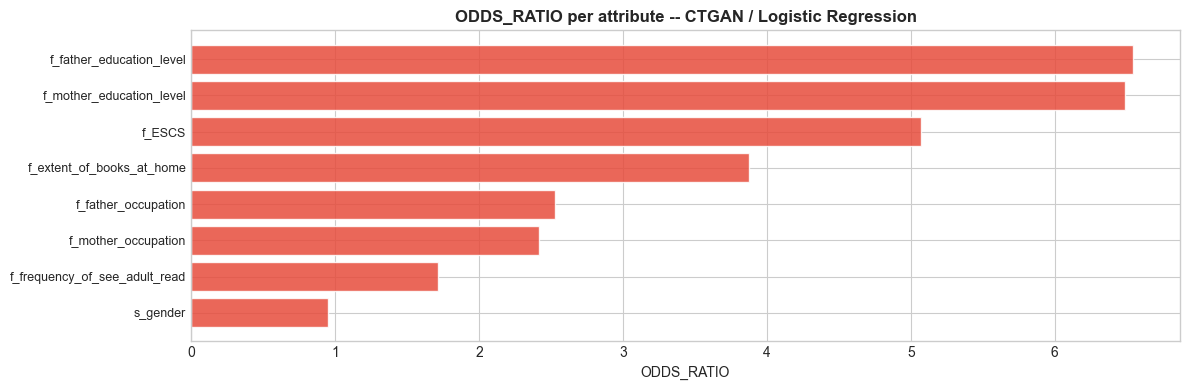

2026-07-10 09:37:16 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_rate_priv_tvae_logistic_regression.png


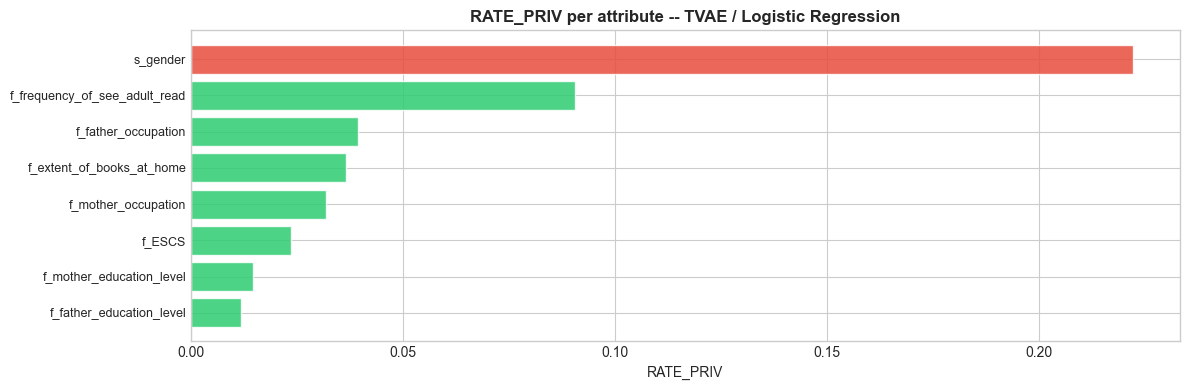

2026-07-10 09:37:17 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_rate_unpriv_tvae_logistic_regression.png


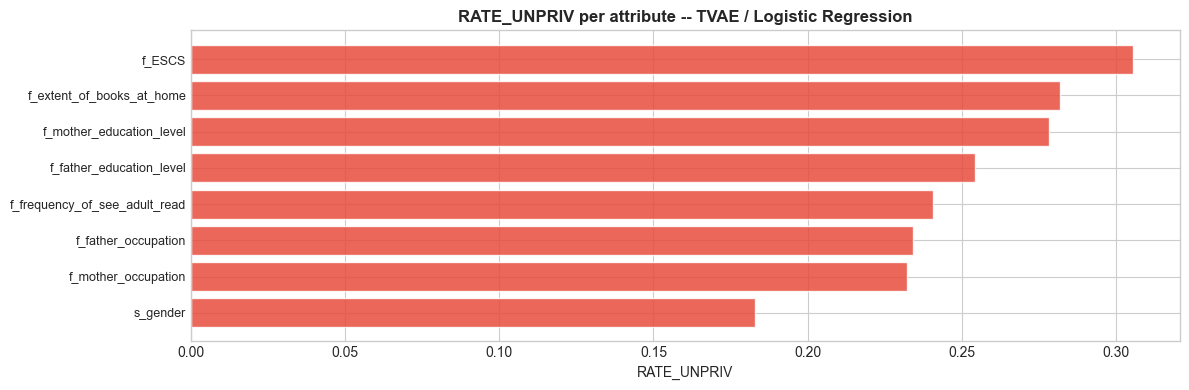

2026-07-10 09:37:18 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_tpr_priv_tvae_logistic_regression.png


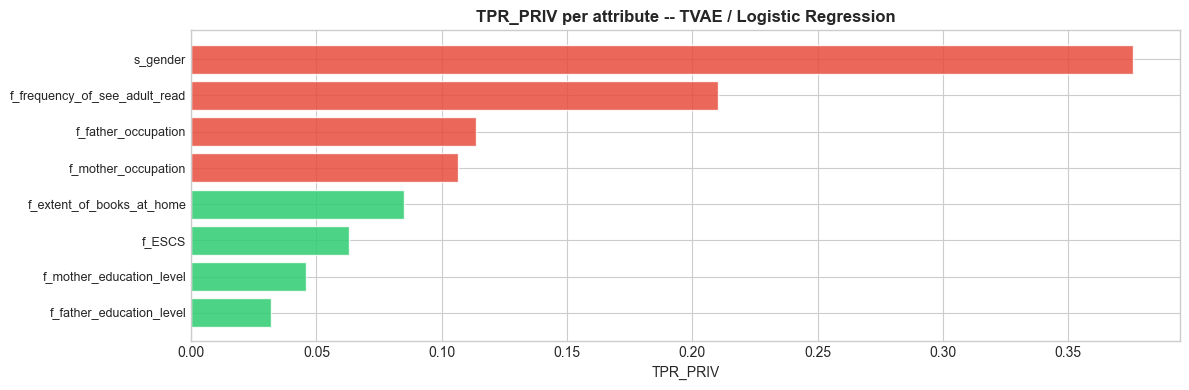

2026-07-10 09:37:18 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_tpr_unpriv_tvae_logistic_regression.png


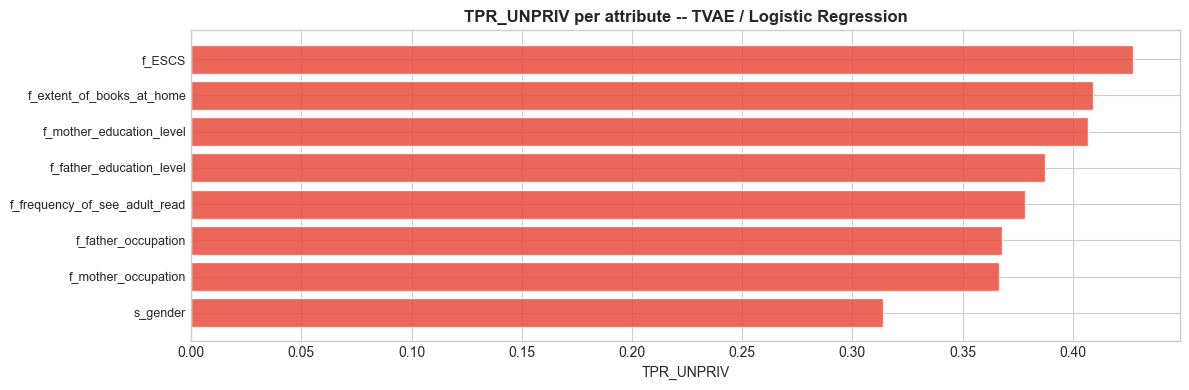

2026-07-10 09:37:19 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_fpr_priv_tvae_logistic_regression.png


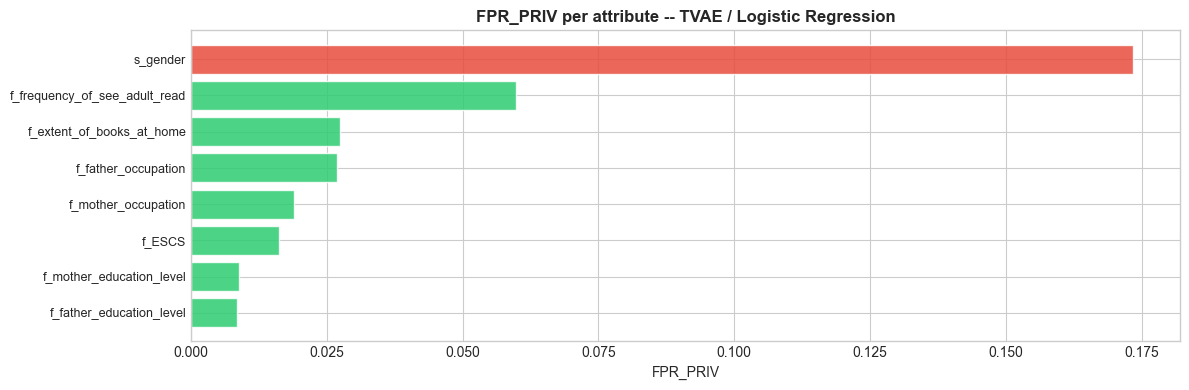

2026-07-10 09:37:20 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_fpr_unpriv_tvae_logistic_regression.png


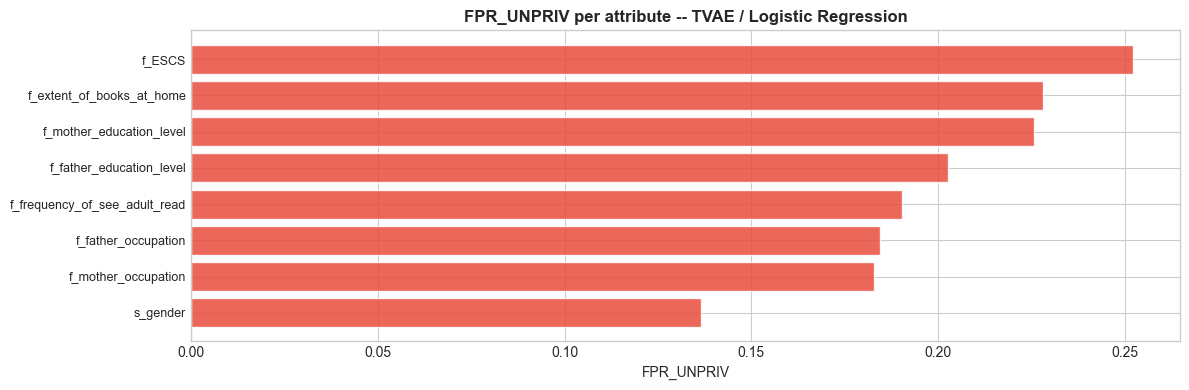

2026-07-10 09:37:20 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_tvae_logistic_regression.png


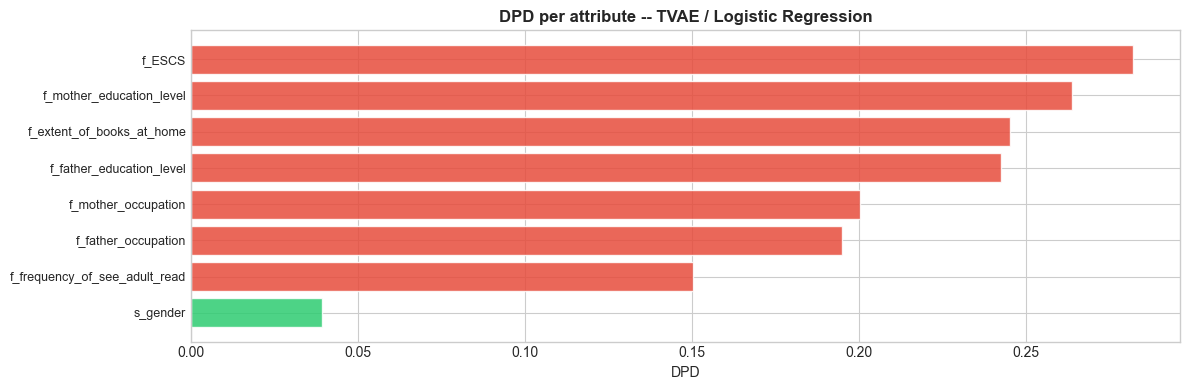

2026-07-10 09:37:21 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_delta_tpr_tvae_logistic_regression.png


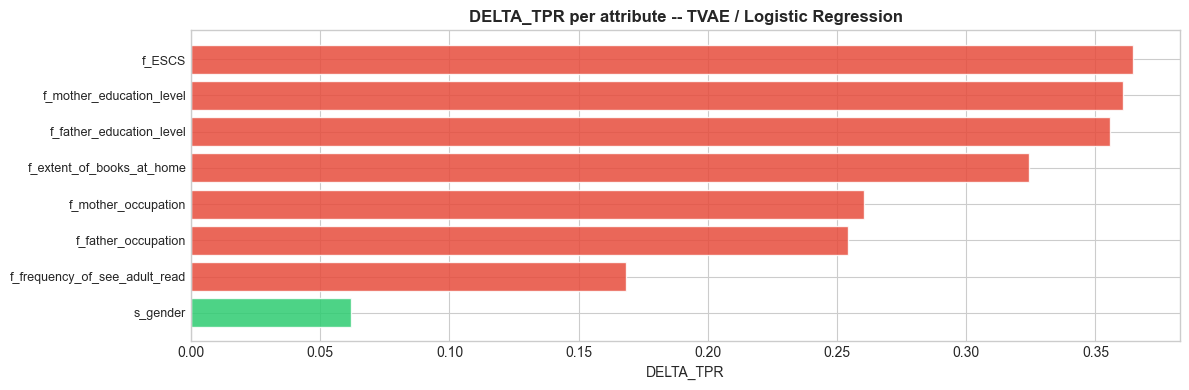

2026-07-10 09:37:22 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_delta_fpr_tvae_logistic_regression.png


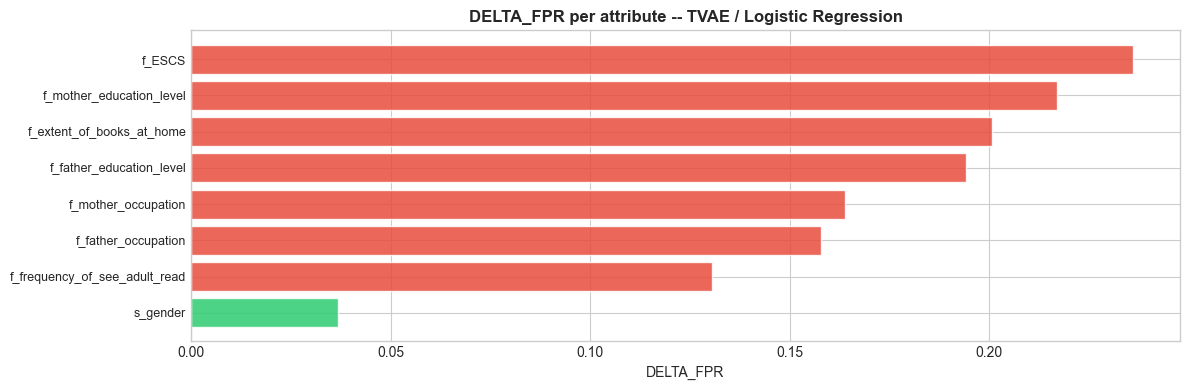

2026-07-10 09:37:22 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_tvae_logistic_regression.png


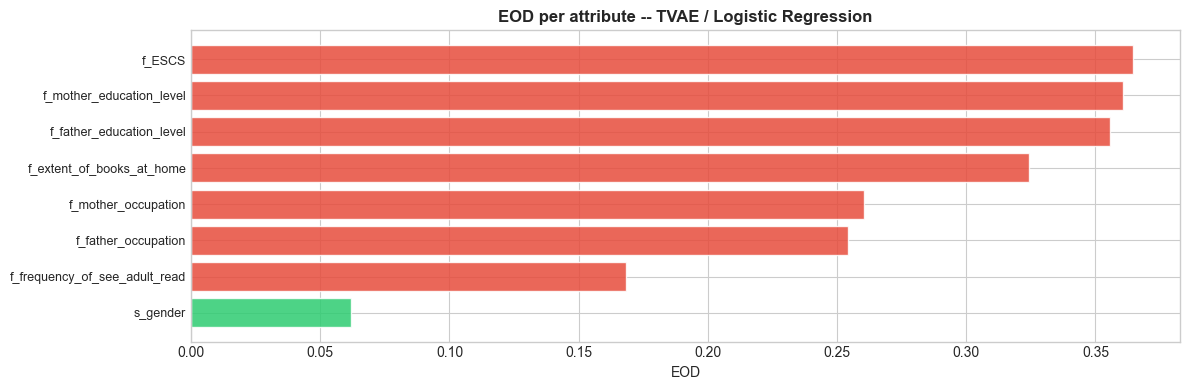

2026-07-10 09:37:23 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_tvae_logistic_regression.png


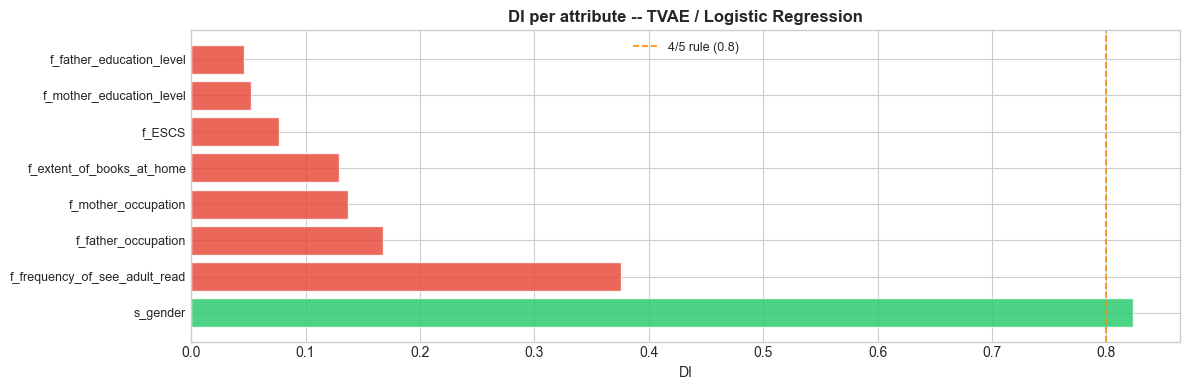

2026-07-10 09:37:23 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_odds_ratio_tvae_logistic_regression.png


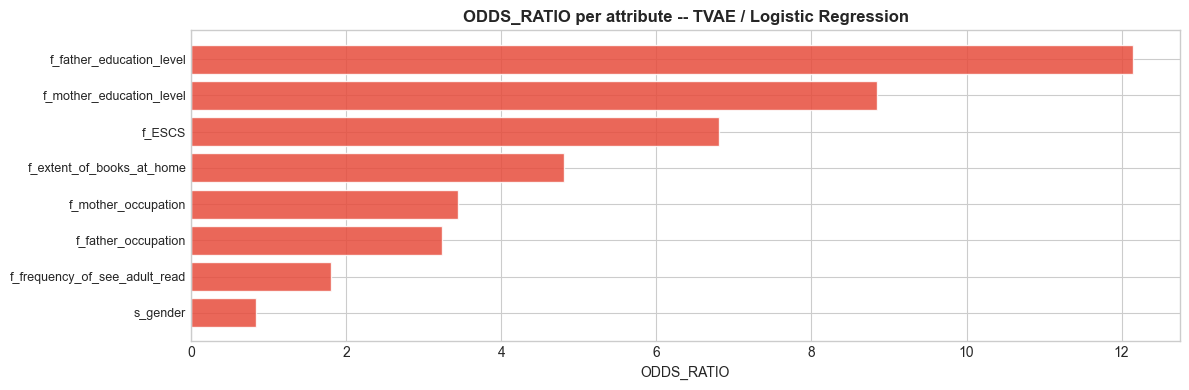

2026-07-10 09:37:24 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_rate_priv_gaussian_copula_logistic_regression.png


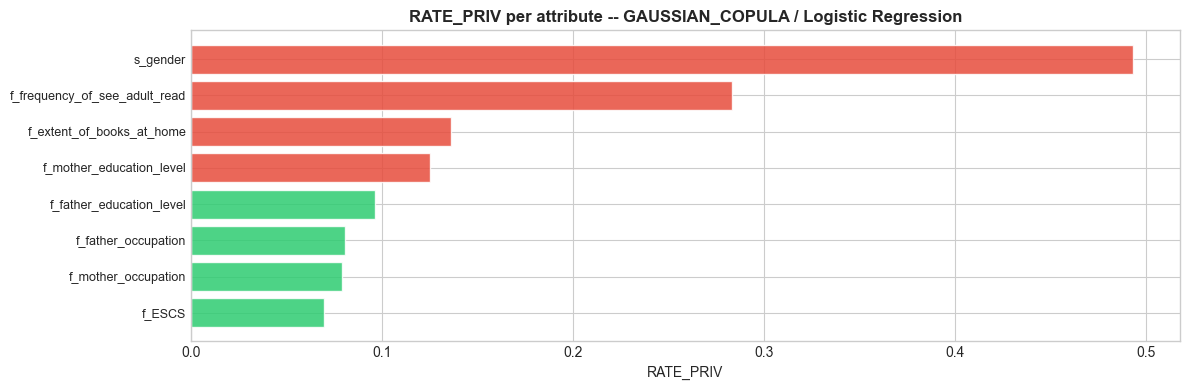

2026-07-10 09:37:25 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_rate_unpriv_gaussian_copula_logistic_regression.png


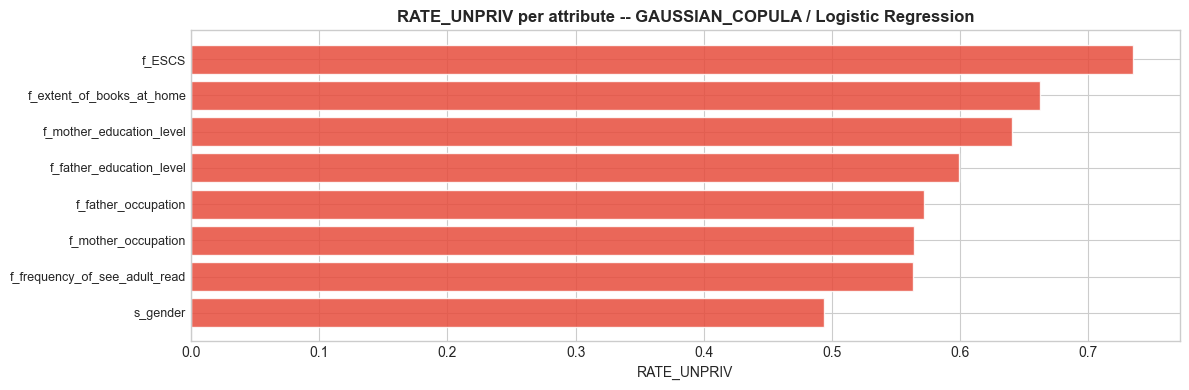

2026-07-10 09:37:25 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_tpr_priv_gaussian_copula_logistic_regression.png


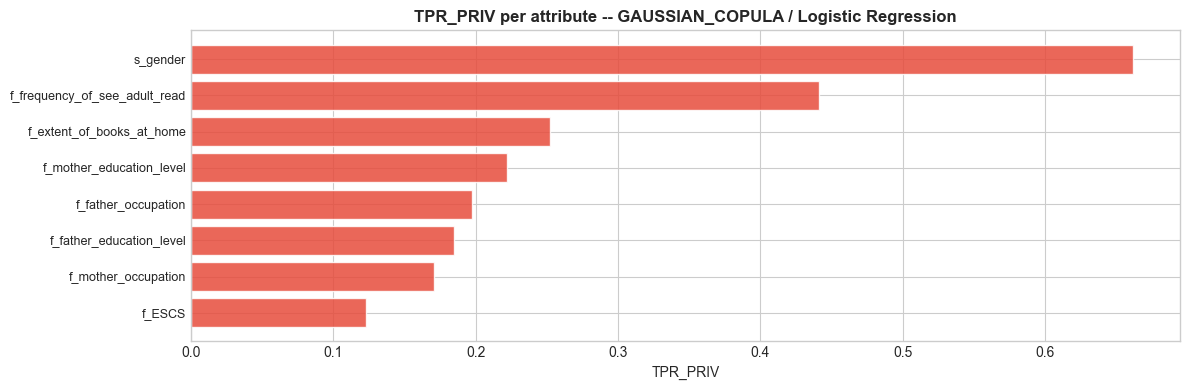

2026-07-10 09:37:26 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_tpr_unpriv_gaussian_copula_logistic_regression.png


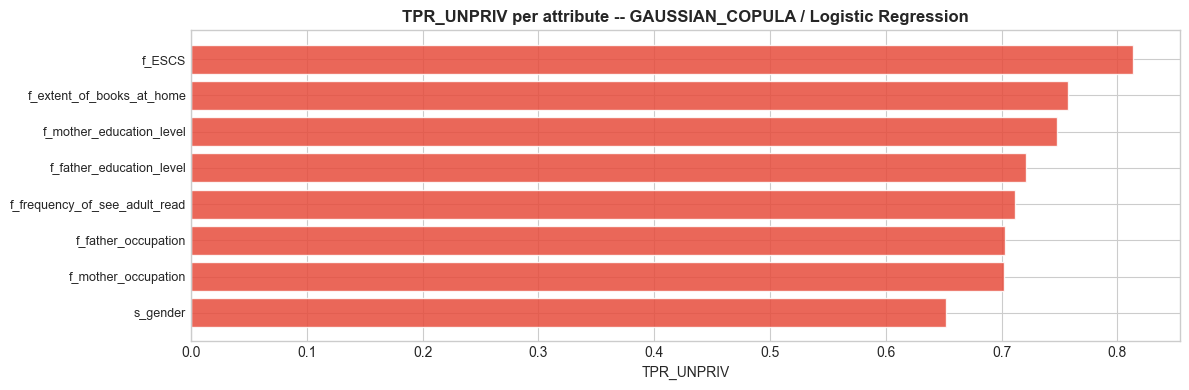

2026-07-10 09:37:27 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_fpr_priv_gaussian_copula_logistic_regression.png


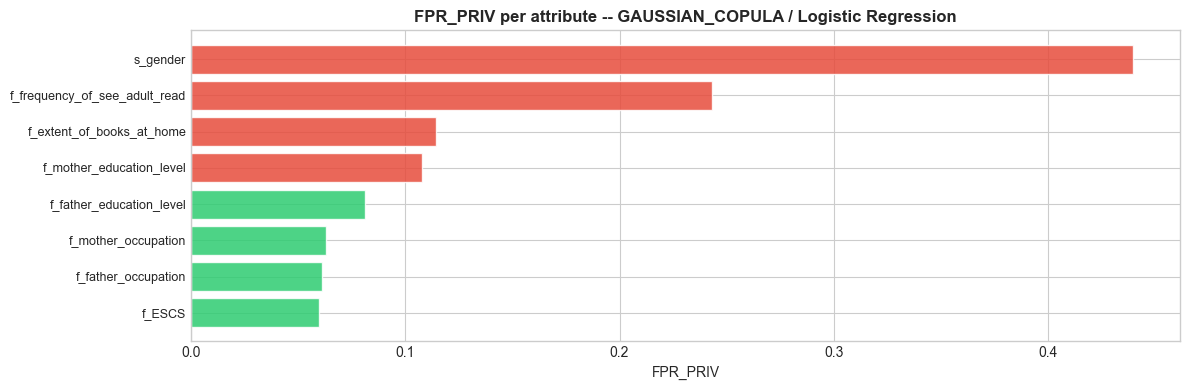

2026-07-10 09:37:27 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_fpr_unpriv_gaussian_copula_logistic_regression.png


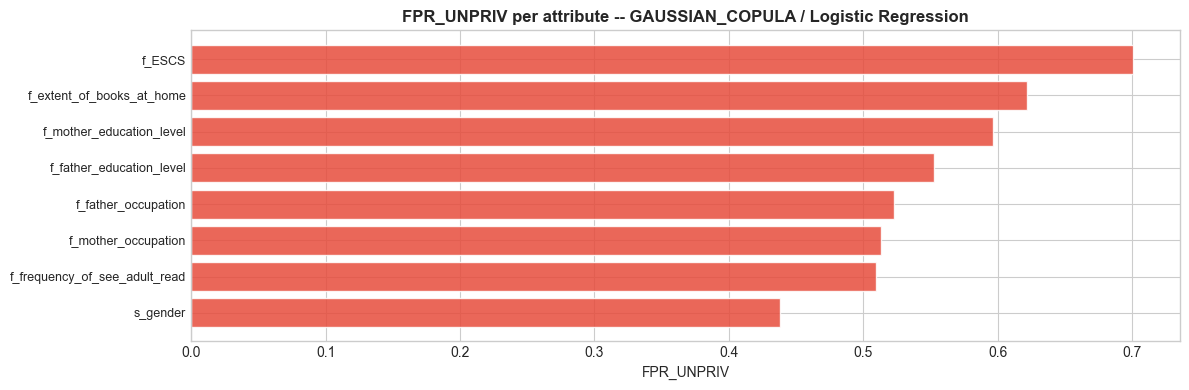

2026-07-10 09:37:28 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_gaussian_copula_logistic_regression.png


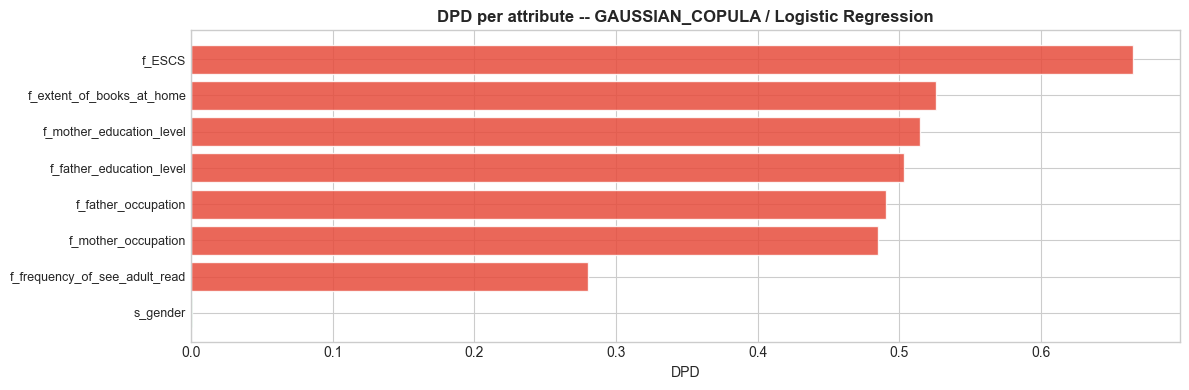

2026-07-10 09:37:29 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_delta_tpr_gaussian_copula_logistic_regression.png


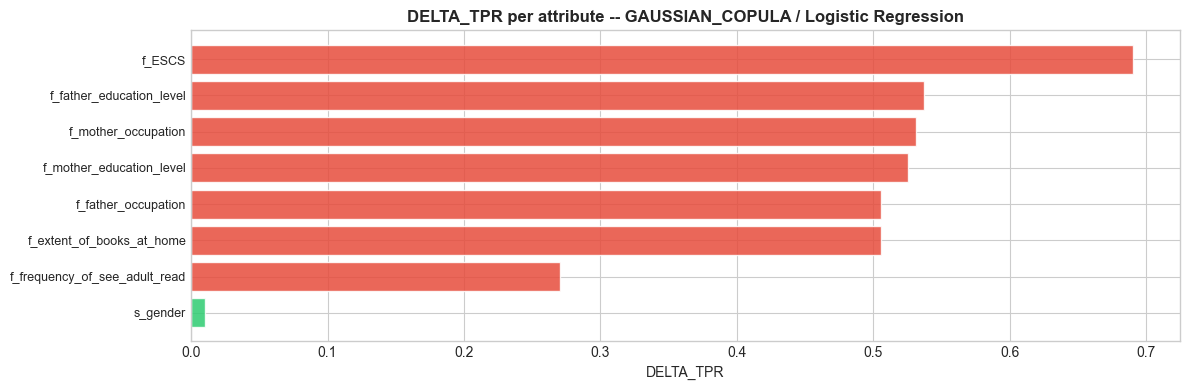

2026-07-10 09:37:30 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_delta_fpr_gaussian_copula_logistic_regression.png


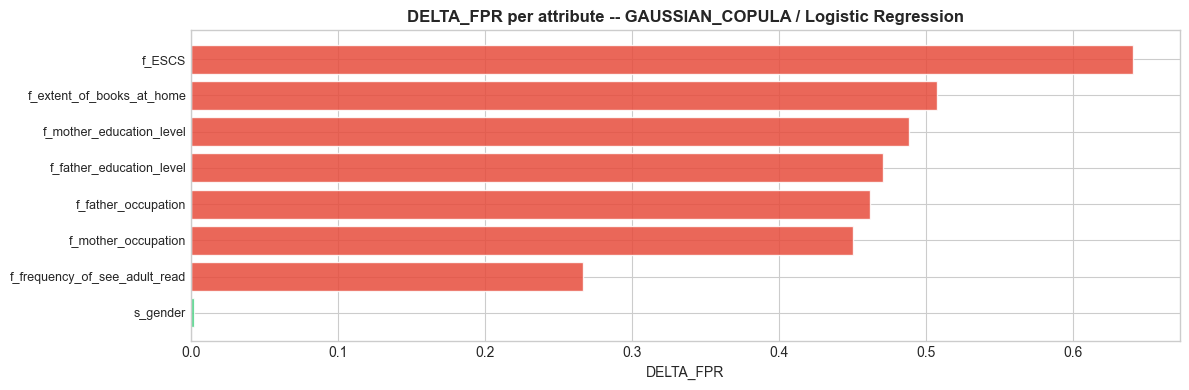

2026-07-10 09:37:31 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_gaussian_copula_logistic_regression.png


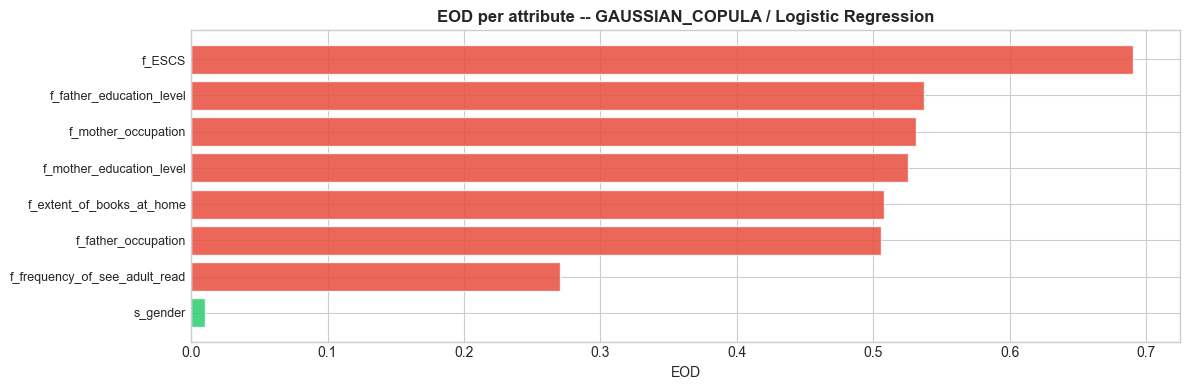

2026-07-10 09:37:31 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_gaussian_copula_logistic_regression.png


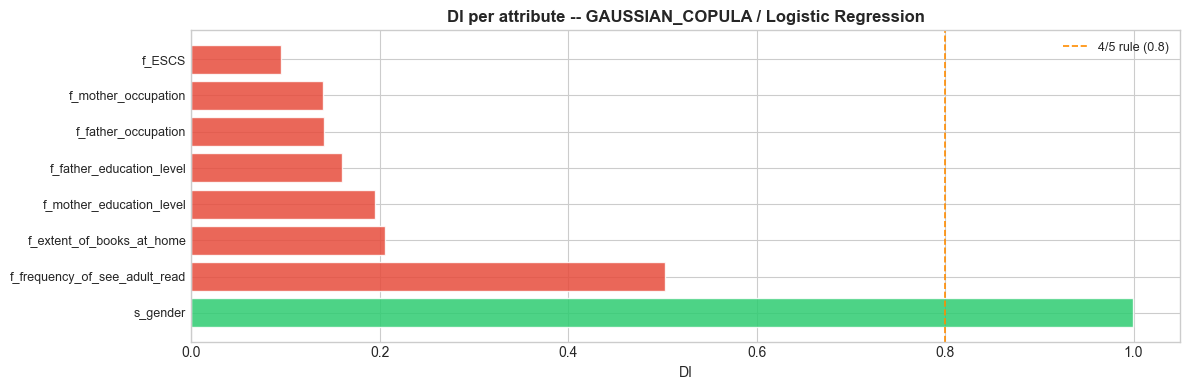

2026-07-10 09:37:32 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_odds_ratio_gaussian_copula_logistic_regression.png


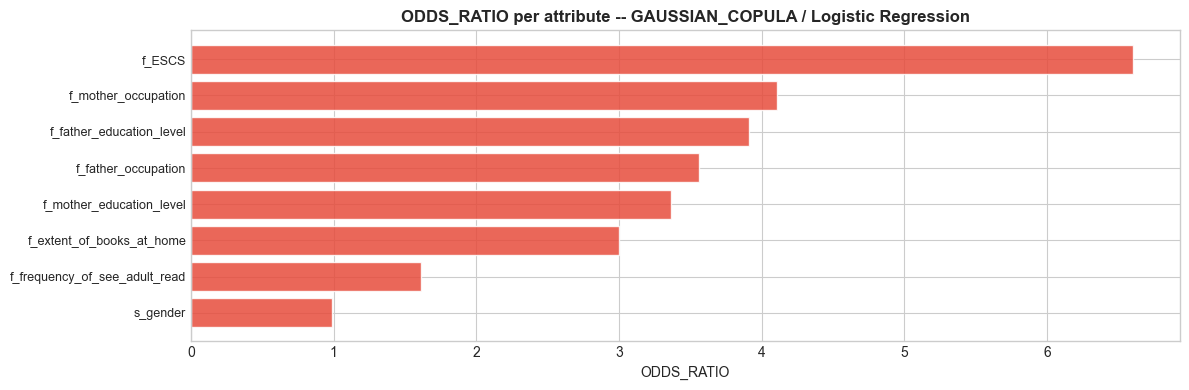

2026-07-10 09:37:33 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_rate_priv_smote_low_perf_xgboost.png


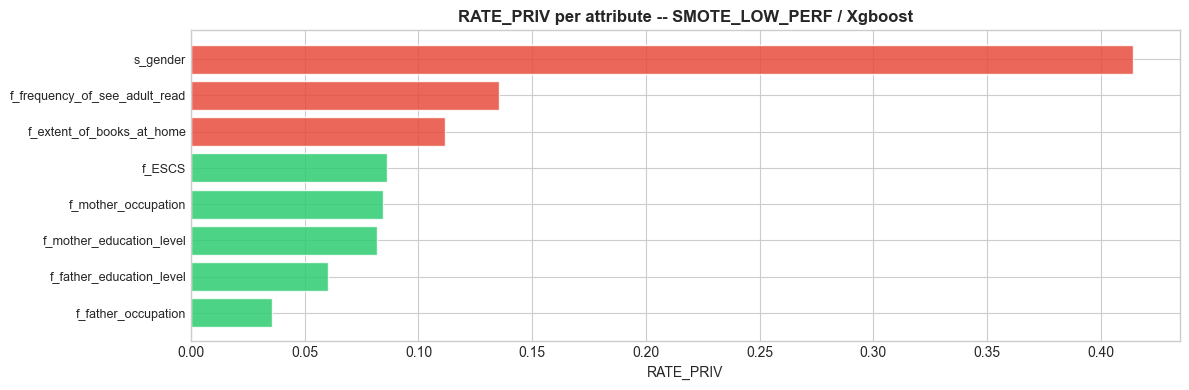

2026-07-10 09:37:34 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_rate_unpriv_smote_low_perf_xgboost.png


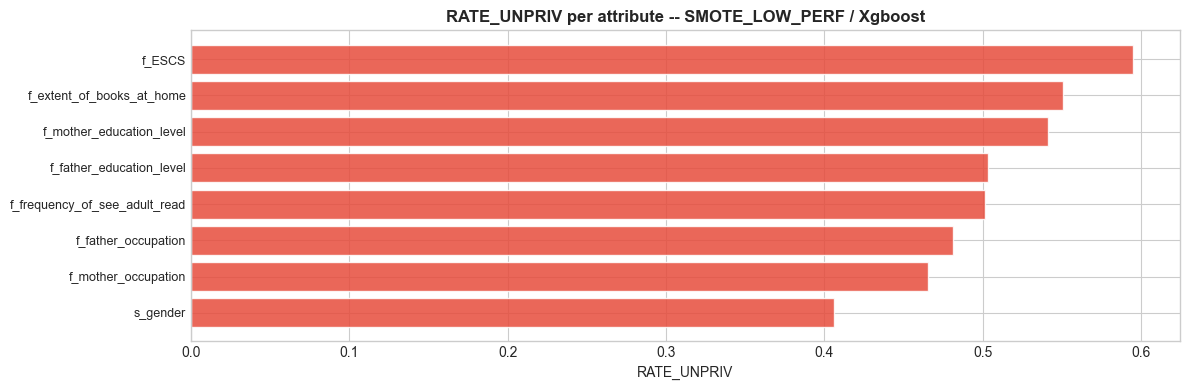

2026-07-10 09:37:34 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_tpr_priv_smote_low_perf_xgboost.png


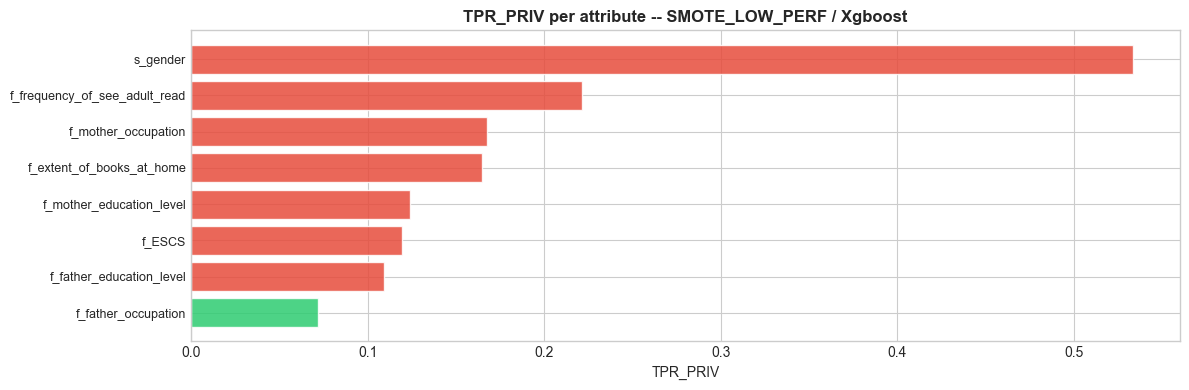

2026-07-10 09:37:35 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_tpr_unpriv_smote_low_perf_xgboost.png


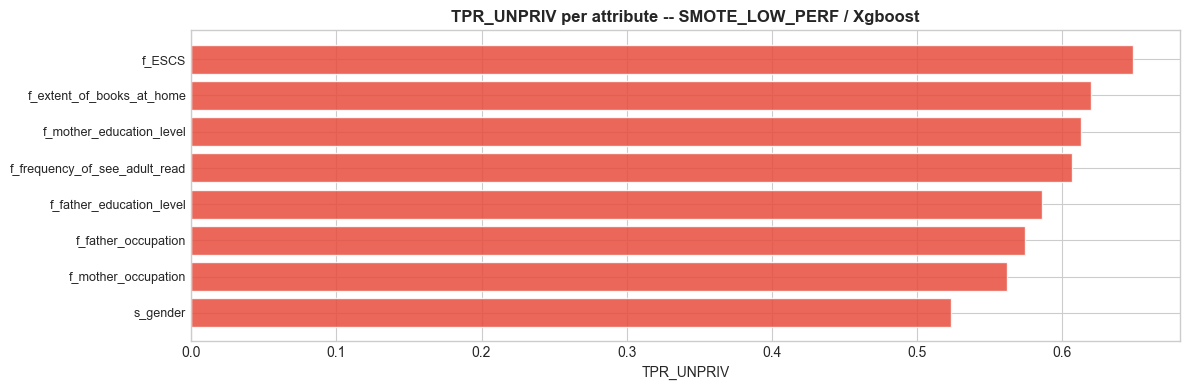

2026-07-10 09:37:36 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_fpr_priv_smote_low_perf_xgboost.png


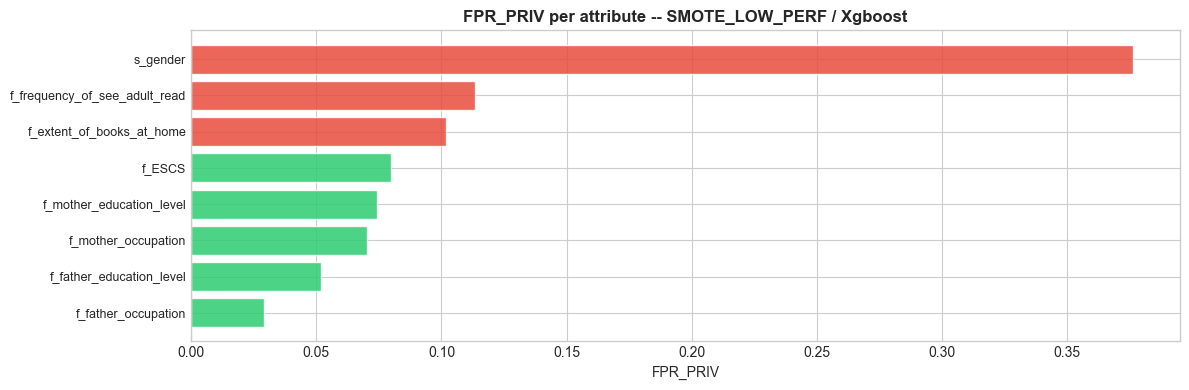

2026-07-10 09:37:37 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_fpr_unpriv_smote_low_perf_xgboost.png


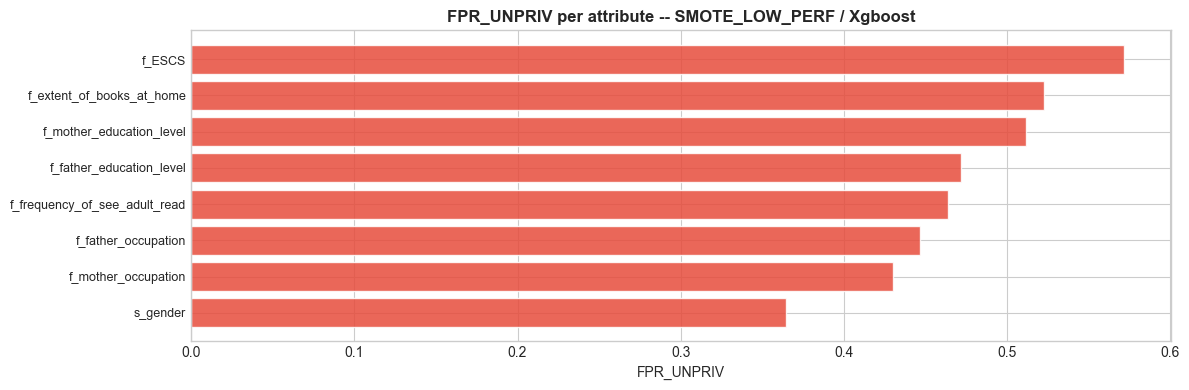

2026-07-10 09:37:37 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_smote_low_perf_xgboost.png


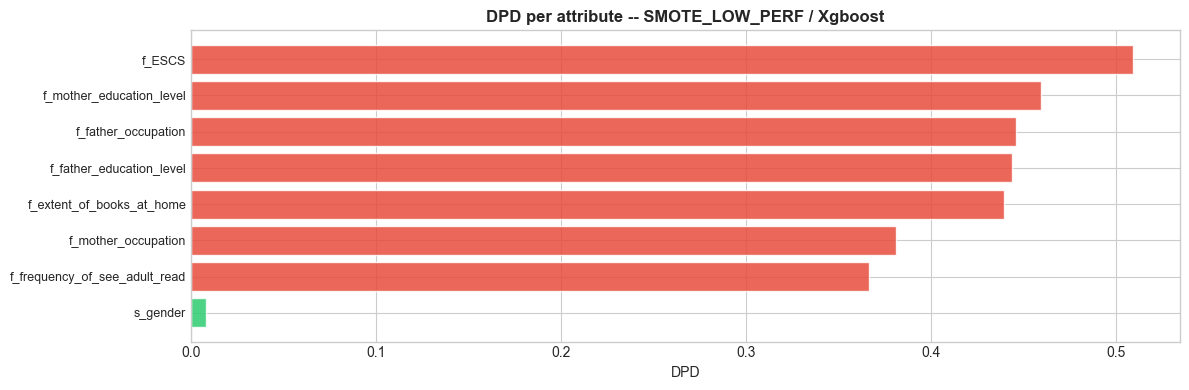

2026-07-10 09:37:38 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_delta_tpr_smote_low_perf_xgboost.png


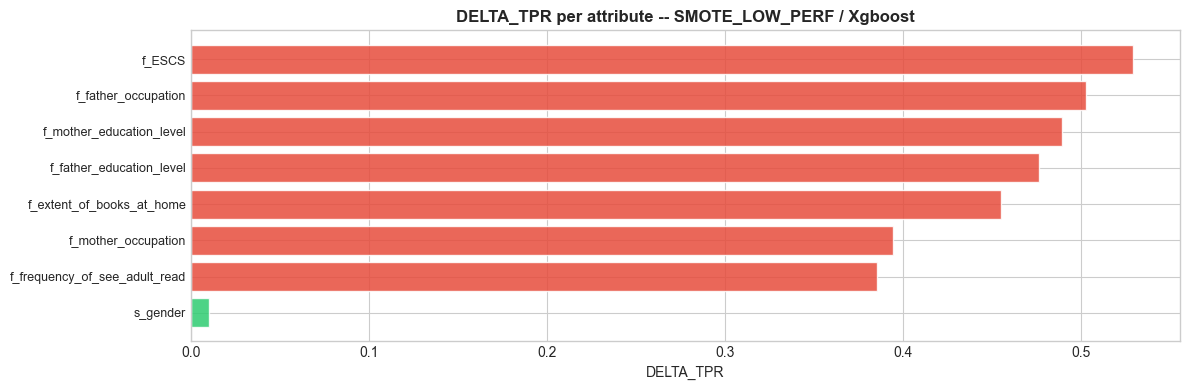

2026-07-10 09:37:39 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_delta_fpr_smote_low_perf_xgboost.png


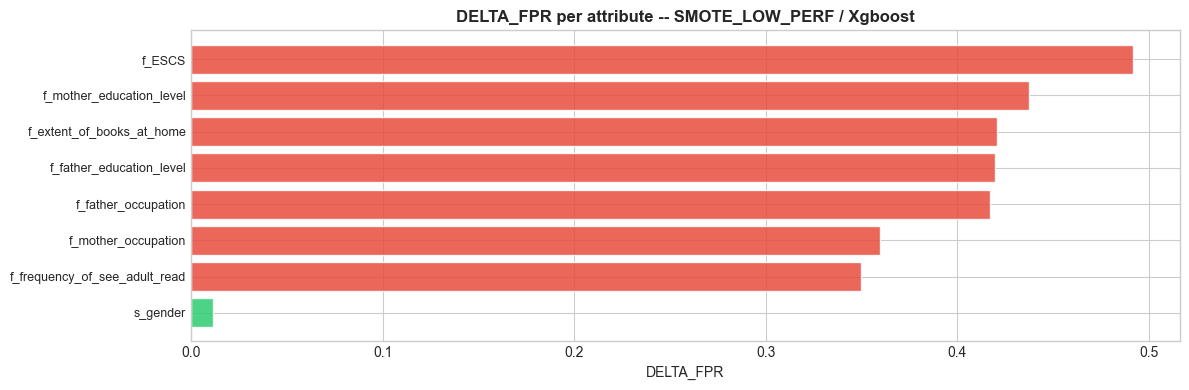

2026-07-10 09:37:39 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_smote_low_perf_xgboost.png


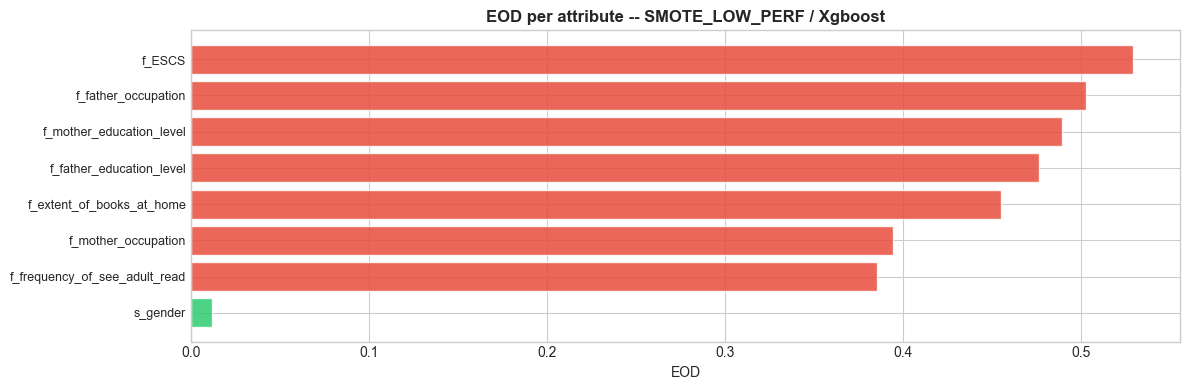

2026-07-10 09:37:40 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_smote_low_perf_xgboost.png


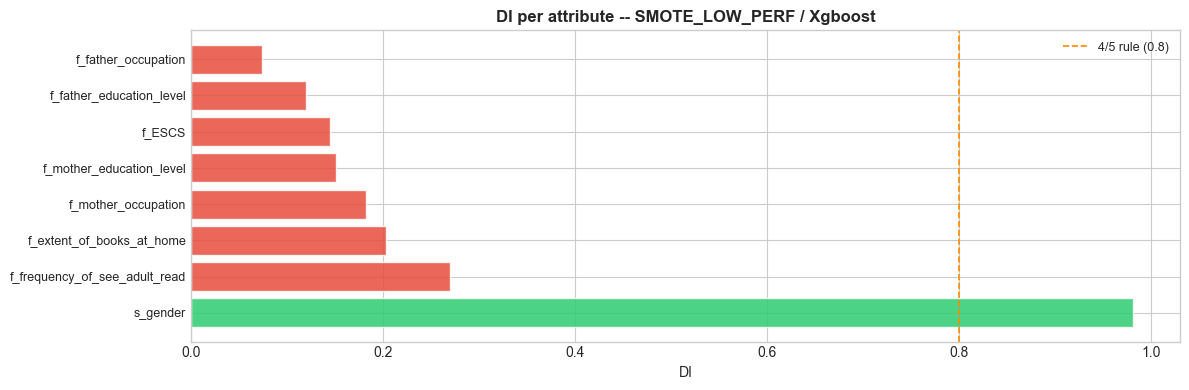

2026-07-10 09:37:41 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_odds_ratio_smote_low_perf_xgboost.png


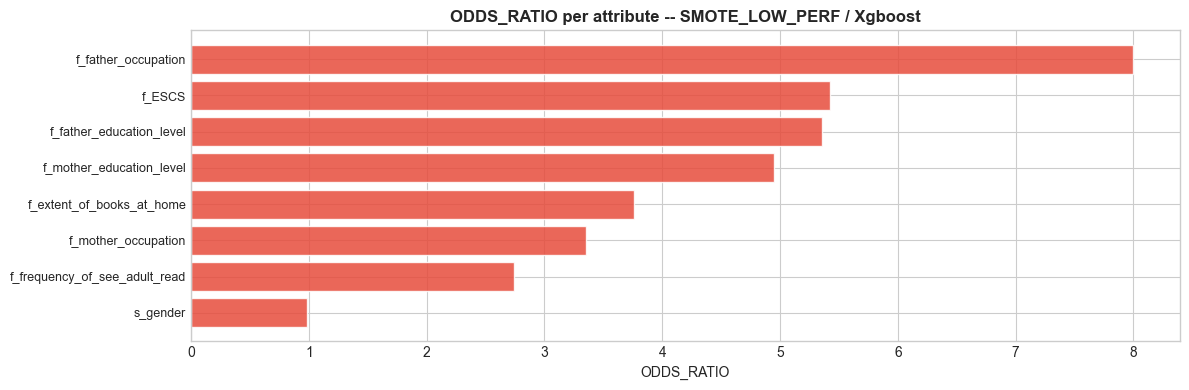

In [35]:
from src.utils.plotting import plot_per_attribute_fairness


# For each generation method, pick the classifier with the highest mean DPD
# (i.e. the worst-case fairness configuration) to highlight in the breakdown.

for method in METHODS:  # matches the synthetic_datasets keys actually loaded above
    # Find the classifier with the highest mean DPD for this method.
    method_rows = metrics_df[metrics_df["method"] == method]

    worst_clf = method_rows.loc[method_rows["mean_dpd"].idxmax(), "classifier"]
    fair_df   = per_attr_fairness[method].get(worst_clf)

    for fairness_metric in [c for c in fair_df.columns if c != "attribute"]:
        title = (
            f"{fairness_metric.upper()} per attribute -- "
            f"{method.upper()} / {worst_clf.replace('_', ' ').title()}"
        )
        save_path = (FIGURES_DIR / f"per_attr_{fairness_metric}.png")
        
        fig = plot_per_attribute_fairness(
            fair_df,
            metric    = fairness_metric,
            cfg       = cfg,
            title     = title,
            save = True,
            filename_suffix = f"_{method}_{worst_clf}"
        )
        plt.show(); plt.close()

## 6. Summary Statistics

### 6.1 Utility summary table

Mean utility metrics across classifiers, grouped by generation method. This collapses the classifier dimension to give a method-level picture of utility performance.

In [36]:
util_cols = [
    m for m in list(metrics_df.columns)
    if m not in ("method", "classifier", "mmd")
    and pd.api.types.is_numeric_dtype(metrics_df[m])
]

utility_summary = metrics_df.groupby("method")[util_cols].mean().round(4)

# Add MMD column (method-level, not classifier-level).
utility_summary["mmd"] = metrics_df.groupby("method")["mmd"].first().round(4)

display(utility_summary)

save_csv(utility_summary.reset_index(), EXPERIMENTS_DIR / "utility_summary.csv")

,balanced_accuracy,f1_macro,roc_auc,brier_score,mean_dpd,mean_eod,mean_di,mean_odds_ratio,s_gender_dpd,s_gender_eod,...,f_ESCS_eod,f_ESCS_di,f_ESCS_odds_ratio,repetition,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,corr_mean_abs_delta,corr_max_abs_delta,mmd
method,,,,,,,,,,,,,,,,,,,,,
ctgan,0.6161,0.5898,0.6712,0.2133,0.3477,0.3854,0.2724,3.9113,0.0191,0.0303,...,0.5326,0.1101,5.1559,0.0,-0.0064,-0.0232,0.0246,0.0410,0.3329,0.0052
gaussian_copula,0.5699,0.5120,0.6378,0.2168,0.2819,0.2891,0.2485,2.1243,0.0009,0.0064,...,0.4252,0.0873,5.3742,0.0,0.0397,0.0547,0.0580,0.0712,0.7194,0.0054
real,0.6096,0.5667,0.6958,0.2048,0.2777,0.2991,0.2967,3.8766,0.0374,0.0356,...,0.4075,0.1449,5.8481,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
smote_low_perf,0.5945,0.5660,0.6379,0.2915,0.3658,0.3907,0.2887,3.5308,0.0288,0.0416,...,0.5054,0.1768,4.3242,0.0,0.0151,0.0007,0.0579,0.0189,0.6697,0.0095
tvae,0.5604,0.5551,0.6531,0.2181,0.1226,0.1675,0.2332,5.8733,0.0288,0.0499,...,0.2337,0.0669,9.0156,0.0,0.0493,0.0115,0.0427,NaN,NaN,0.0121


2026-07-10 09:37:41 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\utility_summary.csv


### 6.2 Fairness summary table

Mean fairness metrics across classifiers, grouped by generation method.

In [37]:
fairness_summary_cols = [c for c in metrics_df.columns if c.startswith("mean_")]

fairness_summary = metrics_df.groupby("method")[fairness_summary_cols].mean().round(4)

display(fairness_summary)

save_csv(fairness_summary.reset_index(), EXPERIMENTS_DIR / "fairness_summary.csv")

,mean_dpd,mean_eod,mean_di,mean_odds_ratio
method,,,,
ctgan,0.3477,0.3854,0.2724,3.9113
gaussian_copula,0.2819,0.2891,0.2485,2.1243
real,0.2777,0.2991,0.2967,3.8766
smote_low_perf,0.3658,0.3907,0.2887,3.5308
tvae,0.1226,0.1675,0.2332,5.8733


2026-07-10 09:37:41 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\fairness_summary.csv


### 6.3 Delta summary table

Mean deltas relative to the real baseline, grouped by generation method. This is the primary table for the report's Results section, as it directly quantifies the cost of anonymisation in terms of both utility and fairness.

In [38]:
delta_cols_all = util_delta_cols + fair_delta_cols

if delta_cols_all:
    delta_syn_subset = delta_df[
        (delta_df["method"] != baseline_label)
    ]
    delta_summary = delta_syn_subset.groupby("method")[delta_cols_all].mean().round(4)
    
    display(delta_summary)

    save_csv(delta_summary.reset_index(), EXPERIMENTS_DIR / "delta_summary.csv")

,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,delta_brier_score,delta_mmd,delta_mean_dpd,delta_mean_eod,delta_mean_di,delta_mean_odds_ratio
method,,,,,,,,,
ctgan,0.0064,0.0232,-0.0246,0.0085,0.0052,0.0700,0.0863,-0.0243,0.0347
gaussian_copula,-0.0397,-0.0547,-0.0580,0.0120,0.0054,0.0042,-0.0101,-0.0482,-1.7523
smote_low_perf,-0.0151,-0.0007,-0.0579,0.0867,0.0095,0.0881,0.0916,-0.0080,-0.3458
tvae,-0.0493,-0.0115,-0.0427,0.0133,0.0121,-0.1551,-0.1316,-0.0635,1.9967


2026-07-10 09:37:41 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\delta_summary.csv


## 7. Outputs Summary

The following artefacts have been produced and saved by this notebook:

| Artefact | Path | Description |
|----------|------|-------------|
| `metrics_matrix.csv` | `results/experiments/` | Raw (method, classifier) × metric matrix |
| `delta_matrix.csv`   | `results/experiments/` | Same, but with Δ columns relative to real baseline |
| `utility_summary.csv`  | `results/experiments/` | Utility metrics averaged across classifiers, per method |
| `fairness_summary.csv` | `results/experiments/` | Fairness metrics averaged across classifiers, per method |
| `delta_summary.csv`    | `results/experiments/` | Mean deltas per method |
| `per_attribute_fairness/` | `results/experiments/` | Per-attribute fairness CSVs (one per config) |
| `*.pdf` figures | `results/figures/experiments/` | All visualisations described in §6 |

These outputs feed directly into **Notebook 5**, where they are interpreted in terms of the project's research questions:
- **Q1**: How much utility is lost under synthetic training data?
- **Q2**: How does synthetic generation alter standard fairness metrics?
- **Q3 (exploratory)**: Is utility loss correlated with fairness degradation?